In [1]:
# from data_synthesizer.util import  plot_training_loss, ModelType
from typing import Tuple
import pandas as pd
import pickle

from data_loader import DataLoader
from data_synthesizer.sdv import SDVCTGAN_, SDVTVAE_
from data_evaluator import ClassifierType
from data_synthesizer.pipeline import PipelineBuilder, PipelineResults, load_all_results
from data_synthesizer.privacy_sampling import get_epsilon

from evaluation_report.ressemblance_report import ResemblanceReport
from evaluation_report.utility_report import UtilityReport
from evaluation_report.privacy_report import PrivacyReport 
from evaluation_report.privacy_anonymeter_report import PrivacyAnonymeterReport

In [2]:
import sys
from pathlib import Path

# Add repo root so `import experiments` works in notebooks.
sys.path.append(str(Path.cwd().parent.parent))

from experiments.paths import RESULTS_DIR, DATA_DIR, BASELINE_DIR, PRIVACY_ONLY_DIR,PRIVACY_ONLY_DIR_WEIGHTED, PRIVACY_ONLY_DIR_WEIGHTED_5


## Loading Data

### Real Data

In [3]:
cat_list_credit_card = ['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6', 'default.payment.next.month']
num_list_credit_card = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4','BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3','PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
credit_qai_columns = ['LIMIT_BAL','SEX','EDUCATION','MARRIAGE','AGE']
credit_risk_column = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6','BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6','PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6']

df_real_credit_card_train = DataLoader(f'{DATA_DIR}/credit_card_Train.csv').get_dataframe(cat_list_credit_card,  drop_identation=True)
df_real_credit_card_test = DataLoader(f'{DATA_DIR}/credit_card_Test.csv').get_dataframe(cat_list_credit_card,  drop_identation=True)
credit_real_dict ={'data' : df_real_credit_card_train, 'cat_list' : cat_list_credit_card, 'num_list' : num_list_credit_card}

In [4]:
cat_list_adult = ['workclass','education','marital-status','occupation','relationship','race','sex','native-country','income']
num_list_adult = ['age','fnlwgt','education-num','capital-gain','capital-loss','hours-per-week']
adult_qai_columns = ['education','education-num','marital-status','occupation','relationship','sex', 'native-country']
adult_risk_column = ['capital-gain','capital-loss','hours-per-week','income', 'race']
df_real_adult_train = DataLoader(f'{DATA_DIR}/adult_train.csv').get_dataframe(cat_list_adult)
df_real_adult_test = DataLoader(f'{DATA_DIR}/adult_test.csv').get_dataframe(cat_list_adult)

In [5]:
num_list_cardio = ['age', 'height', 'weight', 'ap_hi', 'ap_lo']
cat_list_cardio = ['gender','cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']

cardio_qai_columns = ['age','gender','height','weight']
cardio_risk_column = ['ap_lo','ap_hi','cholesterol','gluc','smoke','alco','active']


df_real_cardio_train = DataLoader(f'{DATA_DIR}/cardio_train.csv').get_dataframe(cat_list_cardio)
df_real_cardio_test = DataLoader(f'{DATA_DIR}/cardio_test.csv').get_dataframe(cat_list_cardio)

### Synthetic data 

In [6]:
from data_synthesizer.pipeline.storages.privacy_results_storage import load_privacy_results


credit_ctgan_privacy  = load_privacy_results(f'{BASELINE_DIR}/credit_ctgan_baseline')

In [7]:
from data_synthesizer.pipeline.storages.resemblance_results_storage import load_resemblance_results


credit_ctgan_resemblance  = load_resemblance_results(f'{BASELINE_DIR}/credit_ctgan_baseline')

In [8]:
credit_ctgan  = load_all_results(f'{BASELINE_DIR}/credit_ctgan_baseline')
credit_tvae  = load_all_results(f'{BASELINE_DIR}/credit_tvae_baseline')

credit_ctgan_heom_any_eps_001  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/credit_ctgan_eps_0.01')
credit_ctgan_heom_any_weighted_eps_001  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any_weighted/credit_ctgan_eps_0.01')
credit_ctgan_heom_any_weighted_5_eps_001  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any_weighted_5/credit_ctgan_eps_0.01')

credit_tvae_heom_any_eps_001  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/credit_tvae_eps_0.01')
credit_tvae_heom_any_weighted_eps_001  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any_weighted/credit_tvae_eps_0.01')
credit_tvae_heom_any_weighted_5_eps_001  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any_weighted_5/credit_tvae_eps_0.01')

dict_results_credit_ctgan  = {
    'credit CTGAN' : credit_ctgan,
    'credit CTGAN V0' : credit_ctgan_heom_any_eps_001,
    'credit CTGAN V1' : credit_ctgan_heom_any_weighted_eps_001,    
    'credit CTGAN V2' : credit_ctgan_heom_any_weighted_5_eps_001,    
}

dict_results_credit_tvae  = {
    'credit TVAE' : credit_tvae,
    'credit TVAE V0' : credit_tvae_heom_any_eps_001,
    'credit TVAE V1' : credit_tvae_heom_any_weighted_eps_001,    
    'credit TVAE V3' : credit_tvae_heom_any_weighted_5_eps_001,    

}

In [9]:
adult_ctgan  = load_all_results(f'{BASELINE_DIR}/adult_ctgan_baseline')
adult_tvae  = load_all_results(f'{BASELINE_DIR}/adult_tvae_baseline')

adult_ctgan_heom_any_eps_001  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/adult_ctgan_eps_0.01')
adult_ctgan_heom_any_weighted_eps_001  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any_weighted/adult_ctgan_eps_0.01')
adult_ctgan_heom_any_weighted_5_eps_001  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any_weighted_5/adult_ctgan_eps_0.01')

adult_tvae_heom_any_eps_001  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/adult_tvae_eps_0.01')
adult_tvae_heom_any_weighted_eps_001  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any_weighted/adult_tvae_eps_0.01')
adult_tvae_heom_any_weighted_5_eps_001  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any_weighted_5/adult_tvae_eps_0.01')

dict_results_adult_ctgan  = {
    'adult CTGAN' : adult_ctgan,
    'adult CTGAN V0' : adult_ctgan_heom_any_eps_001,
    'adult CTGAN V1' : adult_ctgan_heom_any_weighted_eps_001,    
    'adult CTGAN V2' : adult_ctgan_heom_any_weighted_5_eps_001,    
}

dict_results_adult_tvae  = {
    'adult TVAE' : adult_tvae,
    'adult TVAE V0' : adult_tvae_heom_any_eps_001,
    'adult TVAE V1' : adult_tvae_heom_any_weighted_eps_001,    
    'adult TVAE V2' : adult_tvae_heom_any_weighted_5_eps_001,    

}

In [10]:
cardio_ctgan  = load_all_results(f'{BASELINE_DIR}/cardio_ctgan_baseline')
cardio_tvae  = load_all_results(f'{BASELINE_DIR}/cardio_tvae_baseline')

cardio_ctgan_heom_any_eps_001  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/cardio_ctgan_eps_0.01')
cardio_ctgan_heom_any_weighted_eps_001  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any_weighted/cardio_ctgan_eps_0.01')
cardio_ctgan_heom_any_weighted_5_eps_001  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any_weighted_5/cardio_ctgan_eps_0.01')

cardio_tvae_heom_any_eps_001  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any/cardio_tvae_eps_0.01')
cardio_tvae_heom_any_weighted_eps_001  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any_weighted/cardio_tvae_eps_0.01')
cardio_tvae_heom_any_weighted_5_eps_001  = load_all_results(f'{RESULTS_DIR}/epsilon_comparison_heom_any_weighted_5/cardio_tvae_eps_0.01')

dict_results_cardio_ctgan  = {
    'cardio CTGAN' : cardio_ctgan,
    'cardio CTGAN V0' : cardio_ctgan_heom_any_eps_001,
    'cardio CTGAN V1' : cardio_ctgan_heom_any_weighted_eps_001,    
    'cardio CTGAN V2' : cardio_ctgan_heom_any_weighted_5_eps_001,    
}

dict_results_cardio_tvae  = {
    'cardio TVAE' : cardio_tvae,
    'cardio TVAE V0' : cardio_tvae_heom_any_eps_001,
    'cardio TVAE V1' : cardio_tvae_heom_any_weighted_eps_001,    
    'cardio TVAE V3' : cardio_tvae_heom_any_weighted_5_eps_001,    

}

## Resemblance evaluation

### Utilities

In [10]:
def get_results_spec_dict(results_dict, keys):
    result_spec_dict = dict()
    for result_key, result_value  in results_dict.items() :
        nested_value = result_value
        for key in keys:
            nested_value = nested_value[key]
        result_spec_dict[result_key] = nested_value
    return result_spec_dict 

In [11]:
def get_jensen_shanon_num(results_dict) :
    js_num_dict = get_results_spec_dict(results_dict, ['resemblance_evaluation_results','numerical_univariate','univariate_num_js','JS_divergence'])
    return js_num_dict

def get_cohen_num(results_dict) :
    cohen_num = get_results_spec_dict(results_dict, ['resemblance_evaluation_results','numerical_univariate','univariate_num_js','cohen_s_d'])
    return cohen_num

def get_jensen_shanon_cat(results_dict) :
    js_cat = get_results_spec_dict(results_dict, ['resemblance_evaluation_results','categorical_univariate','jensen_shanon','JS_divergence'])
    return js_cat

def get_diff_norm_cramer_cat(results_dict) :
    js_cat = get_results_spec_dict(results_dict, ['resemblance_evaluation_results','categorical_multivariate','diff_norm_cramer'])
    return js_cat  

def get_cramer_spearman_correlation_coefficient_cat(results_dict) :
    js_cat = get_results_spec_dict(results_dict, ['resemblance_evaluation_results','categorical_multivariate','cramer_spearman_correlation_coefficient'])
    return js_cat  

def get_diff_norm_pearson_num(results_dict) :
    js_cat = get_results_spec_dict(results_dict, ['resemblance_evaluation_results','numerical_multivariate','pearson_norm_diff'])
    return js_cat  

def get_pearson_spearman_correlation_coefficient_num(results_dict) :
    js_cat = get_results_spec_dict(results_dict, ['resemblance_evaluation_results','numerical_multivariate','pearson_spearman_correlation_coefficient'])
    return js_cat  

def get_corr_ratio_spearman_correlation_coefficient_catnum(results_dict) :
    js_cat = get_results_spec_dict(results_dict, ['resemblance_evaluation_results','categorical_numerical_multivariate','corr_ratio_spearman_correlation_coefficient'])
    return js_cat  

def get_diff_norm_corr_ratio_catnum(results_dict) :
    js_cat = get_results_spec_dict(results_dict, ['resemblance_evaluation_results','categorical_numerical_multivariate','diff_norm_corr_ratio'])
    return js_cat  


In [22]:
js = {}
js['credit CTGAN'] = get_jensen_shanon_cat(dict_results_credit_ctgan)
js['credit TVAE'] = get_jensen_shanon_cat(dict_results_credit_tvae)
js['adult CTGAN'] = get_jensen_shanon_cat(dict_results_adult_ctgan)
js['adult TVAE'] = get_jensen_shanon_cat(dict_results_adult_tvae)
js['cardio CTGAN'] = get_jensen_shanon_cat(dict_results_cardio_ctgan)
js['cardio TVAE'] = get_jensen_shanon_cat(dict_results_cardio_tvae)
js

{'credit CTGAN': {'credit CTGAN': SEX                           0.069132
  EDUCATION                     0.103745
  MARRIAGE                      0.103999
  PAY_0                         0.228912
  PAY_2                         0.239390
  PAY_3                         0.257477
  PAY_4                         0.263425
  PAY_5                         0.253921
  PAY_6                         0.245978
  default.payment.next.month    0.090560
  Name: JS_divergence, dtype: float64,
  'credit CTGAN no-weighted': SEX                           0.065770
  EDUCATION                     0.123952
  MARRIAGE                      0.118717
  PAY_0                         0.188995
  PAY_2                         0.204637
  PAY_3                         0.220814
  PAY_4                         0.234917
  PAY_5                         0.225932
  PAY_6                         0.227524
  default.payment.next.month    0.069717
  Name: JS_divergence, dtype: float64,
  'credit CTGAN weighted': SEX            

In [ ]:
get_cramer_spearman_correlation_coefficient_cat(dict_results_credit_ctgan)

{'credit CTGAN': 0.9407114624505929,
 'credit CTGAN no-weighted': 0.9245059288537548,
 'credit CTGAN weighted': 0.9366271409749669,
 'credit CTGAN weighted 5': 0.8454545454545455}

In [11]:
get_cramer_spearman_correlation_coefficient_cat(dict_results_credit_tvae)

{'credit TVAE': 0.8891963109354413,
 'credit TVAE no-weighted': 0.8503293807641633,
 'credit TVAE weighted': 0.8479578392621869,
 'credit TVAE weighted 5': 0.772859025032938}

In [12]:
get_cramer_spearman_correlation_coefficient_cat(dict_results_adult_ctgan)

{'adult CTGAN': 0.9132561132561132,
 'adult CTGAN no-weighted': 0.8725868725868727,
 'adult CTGAN weighted': 0.9276705276705277,
 'adult CTGAN weighted 5': 0.9075933075933075}

In [13]:
get_cramer_spearman_correlation_coefficient_cat(dict_results_adult_tvae)

{'adult TVAE': 0.8661518661518662,
 'adult TVAE no-weighted': 0.857915057915058,
 'adult TVAE weighted': 0.8561132561132561,
 'adult TVAE weighted 5': 0.8823680823680824}

In [24]:
cohen = {}
cohen['credit CTGAN'] = get_cohen_num(dict_results_credit_ctgan)
cohen['credit TVAE'] = get_cohen_num(dict_results_credit_tvae)
cohen['adult CTGAN'] = get_cohen_num(dict_results_adult_ctgan)
cohen['adult TVAE'] = get_cohen_num(dict_results_adult_tvae)
cohen['cardio CTGAN'] = get_cohen_num(dict_results_cardio_ctgan)
cohen['cardio TVAE'] = get_cohen_num(dict_results_cardio_tvae)
cohen 

{'credit CTGAN': {'credit CTGAN': LIMIT_BAL    0.162026
  AGE          0.125175
  BILL_AMT1    0.042574
  BILL_AMT2    0.008990
  BILL_AMT3    0.012994
  BILL_AMT4    0.008451
  BILL_AMT5    0.028362
  BILL_AMT6    0.034053
  PAY_AMT1     0.071188
  PAY_AMT2     0.080350
  PAY_AMT3     0.071670
  PAY_AMT4     0.080610
  PAY_AMT5     0.106549
  PAY_AMT6     0.029853
  Name: cohen_s_d, dtype: float64,
  'credit CTGAN no-weighted': LIMIT_BAL    0.147603
  AGE          0.121861
  BILL_AMT1    0.133736
  BILL_AMT2    0.101399
  BILL_AMT3    0.059570
  BILL_AMT4    0.089146
  BILL_AMT5    0.054048
  BILL_AMT6    0.123287
  PAY_AMT1     0.016569
  PAY_AMT2     0.034586
  PAY_AMT3     0.015640
  PAY_AMT4     0.029801
  PAY_AMT5     0.059851
  PAY_AMT6     0.003727
  Name: cohen_s_d, dtype: float64,
  'credit CTGAN weighted': LIMIT_BAL    0.145151
  AGE          0.115715
  BILL_AMT1    0.132579
  BILL_AMT2    0.102724
  BILL_AMT3    0.062228
  BILL_AMT4    0.090930
  BILL_AMT5    0.049749
  BIL

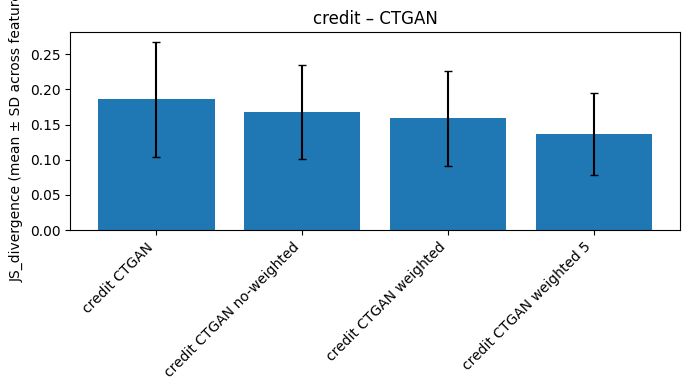

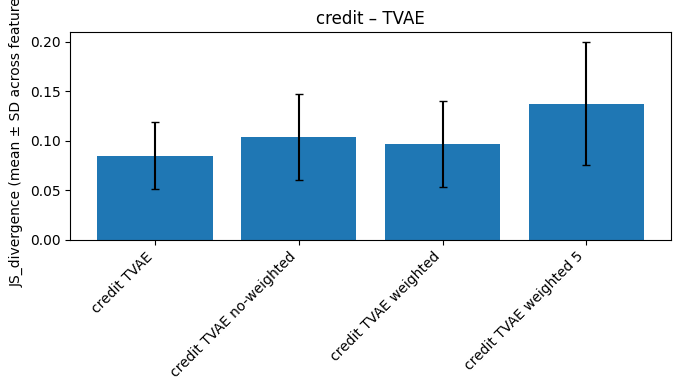

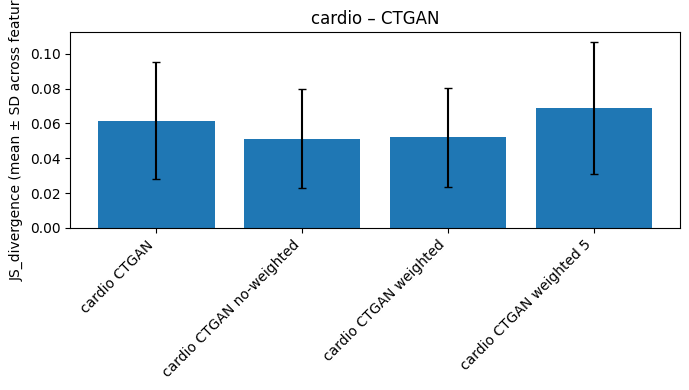

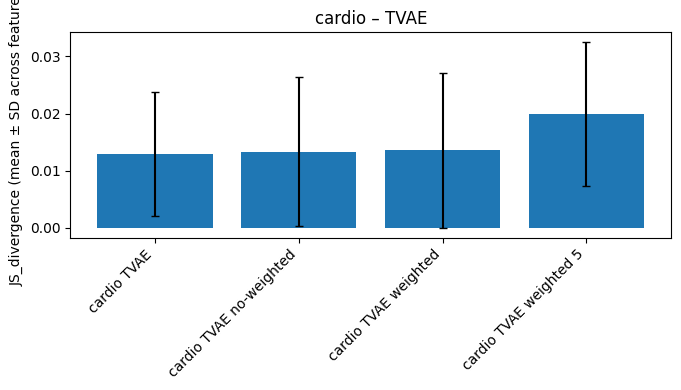

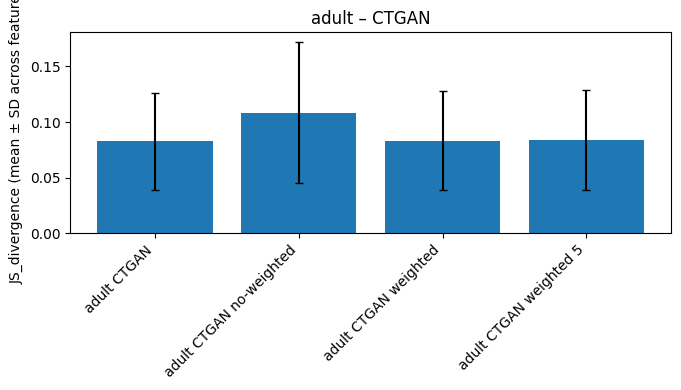

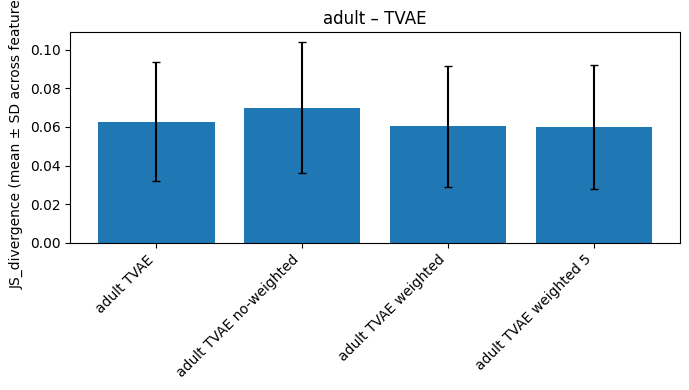

In [29]:
import math
from typing import Dict, Any, Tuple, List
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1) ---- Paste your data here -------------------------------------------------
# IMPORTANT: Replace the placeholders below with your nested dicts exactly as you have them.
# The structure should be: { "<dataset> <generator>": { "<variant>": { "<feature>": value, ... }, ... }, ... }
# It also works if the innermost values are pandas Series instead of dict (it will call .to_dict()).

js_raw: Dict[str, Dict[str, Any]] = {
    # EXAMPLE shape (short demo; replace with your full JS data):
    # "credit CTGAN": {
    #     "credit CTGAN": {"SEX": 0.069132, "EDUCATION": 0.103745, ...},
    #     "credit CTGAN no-weighted": {"SEX": 0.065770, "EDUCATION": 0.123952, ...},
    #     ...
    # },
}

d_raw: Dict[str, Dict[str, Any]] = {
    # EXAMPLE shape for Cohen's d (numerical features). Replace with your real numbers.
    # "credit CTGAN": {
    #     "credit CTGAN": {"LIMIT_BAL": 0.12, "AGE": 0.08, ...},
    #     ...
    # },
}

# 2) ---- Helpers: parse keys, tidy, summarize --------------------------------

def split_dataset_generator(key: str) -> Tuple[str, str]:
    """
    Split keys like 'credit CTGAN' -> ('credit', 'CTGAN').
    If there are more than two tokens, last token is generator, others form dataset name.
    """
    parts = key.strip().split()
    if len(parts) >= 2:
        return (" ".join(parts[:-1]), parts[-1])
    return (key, "")  # fallback

def to_tidy(df_nested: Dict[str, Dict[str, Any]], metric_name: str) -> pd.DataFrame:
    rows: List[Dict[str, Any]] = []
    for ds_gen, variants in df_nested.items():
        dataset, generator = split_dataset_generator(ds_gen)
        for variant, feat_vals in variants.items():
            # Support pandas Series or dict
            if hasattr(feat_vals, "to_dict"):
                feat_vals = feat_vals.to_dict()
            for feature, val in feat_vals.items():
                rows.append({
                    "dataset": dataset,
                    "generator": generator,
                    "variant": variant,
                    "feature": feature,
                    "metric": metric_name,
                    "value": float(val),
                })
    return pd.DataFrame(rows)

def summarize_mean_sd(tidy: pd.DataFrame) -> pd.DataFrame:
    """
    Mean ± SD across features, per (dataset, generator, variant, metric).
    """
    g = tidy.groupby(["dataset", "generator", "variant", "metric"])["value"]
    out = g.agg(mean="mean", sd="std", n="count").reset_index()
    # add a mean±sd string for nice tabling
    out["mean_sd"] = out["mean"].map(lambda x: f"{x:.3f}") + " ± " + out["sd"].map(lambda x: f"{x:.3f}")
    return out.sort_values(["dataset", "generator", "variant", "metric"])

# 3) ---- Build tidy frames and summary table ---------------------------------

tidy_js = to_tidy(js, "JS_divergence")
tidy_d  = to_tidy(cohen,  "Cohen_d")

tidy_all = pd.concat([tidy_js, tidy_d], ignore_index=True)
summary = summarize_mean_sd(tidy_all)

# Save CSV/LaTeX for appendix if you want
summary.to_csv("univariate_summary_mean_sd.csv", index=False)
try:
    with open("univariate_summary_mean_sd.tex", "w", encoding="utf-8") as f:
        f.write(summary.to_latex(index=False, escape=True))
except Exception:
    pass  # to_latex may require LaTeX stack; CSV is always available

# print(summary.head(12))
# print("\nSaved: univariate_summary_mean_sd.csv (and .tex if available)")

# 4) ---- “Top-k worst” features per (dataset, generator, variant, metric) ----

def topk_worst(tidy: pd.DataFrame, k: int = 5) -> pd.DataFrame:
    return (tidy.sort_values(["dataset", "generator", "variant", "metric", "value"], ascending=[True, True, True, True, False])
                 .groupby(["dataset", "generator", "variant", "metric"])
                 .head(k)
                 .reset_index(drop=True))

# worst5 = topk_worst(tidy_all, k=5)
# worst5.to_csv("univariate_top5_worst_features.csv", index=False)
# print("\nSaved: univariate_top5_worst_features.csv")

# 5) ---- Heatmaps for the main paper -----------------------------------------
# One heatmap per (dataset, generator, metric): features on Y, variants on X.

def plot_heatmaps(tidy: pd.DataFrame,
                  metric: str,
                  figsize=(8, 6),
                  vmax=None):
    dsg = tidy[tidy["metric"] == metric].copy()
    for (dataset, generator), df_sub in dsg.groupby(["dataset", "generator"]):
        # Pivot: rows=features, cols=variants, values=value
        pivot = df_sub.pivot_table(index="feature", columns="variant", values="value", aggfunc="mean")
        # Order features by average magnitude (descending) to highlight worst at top
        feature_order = pivot.mean(axis=1).sort_values(ascending=False).index
        pivot = pivot.loc[feature_order]

        plt.figure(figsize=figsize)
        img = plt.imshow(pivot.values, aspect="auto", vmax=vmax)  # default colormap, no colors specified
        plt.title(f"{dataset} – {generator} – {metric}")
        plt.xlabel("Variant")
        plt.ylabel("Feature")
        plt.xticks(ticks=np.arange(pivot.shape[1]), labels=pivot.columns, rotation=60, ha="right")
        plt.yticks(ticks=np.arange(pivot.shape[0]), labels=pivot.index)
        cbar = plt.colorbar(img)
        cbar.set_label(metric)
        plt.tight_layout()
        plt.show()

# Examples (uncomment after you paste real data):
# plot_heatmaps(tidy_js, metric="JS_divergence", figsize=(9, 6))
# plot_heatmaps(tidy_d,  metric="Cohen_d",      figsize=(9, 6))

# 6) ---- Optional: compact bar chart of mean ± SD per variant -----------------

def plot_variant_bars(summary_df: pd.DataFrame, dataset: str, generator: str, metric: str, figsize=(7,4)):
    sub = summary_df[(summary_df["dataset"] == dataset) &
                     (summary_df["generator"] == generator) &
                     (summary_df["metric"] == metric)].copy()
    if sub.empty:
        print(f"No data for {dataset} / {generator} / {metric}")
        return
    x = np.arange(len(sub))
    plt.figure(figsize=figsize)
    plt.bar(x, sub["mean"], yerr=sub["sd"], capsize=3)  # default colors
    plt.xticks(x, sub["variant"], rotation=45, ha="right")
    plt.ylabel(f"{metric} (mean ± SD across features)")
    plt.title(f"{dataset} – {generator}")
    plt.tight_layout()
    plt.show()

# Example:
plot_variant_bars(summary, dataset="credit", generator="CTGAN", metric="JS_divergence")
plot_variant_bars(summary, dataset="credit", generator="TVAE", metric="JS_divergence")
plot_variant_bars(summary, dataset="cardio", generator="CTGAN", metric="JS_divergence")
plot_variant_bars(summary, dataset="cardio", generator="TVAE", metric="JS_divergence")
plot_variant_bars(summary, dataset="adult", generator="CTGAN", metric="JS_divergence")
plot_variant_bars(summary, dataset="adult", generator="TVAE", metric="JS_divergence")


In [17]:
get_diff_norm_cramer_cat(dict_results_credit_ctgan)

{'credit CTGAN': 0.7986,
 'credit CTGAN no-weighted': 0.7146,
 'credit CTGAN weighted': 0.7138,
 'credit CTGAN weighted 5': 1.0576}

In [18]:
get_diff_norm_pearson_num(dict_results_credit_ctgan)

{'credit CTGAN': 0.975,
 'credit CTGAN no-weighted': 0.9898,
 'credit CTGAN weighted': 1.0049,
 'credit CTGAN weighted 5': 1.1102}

## Utility evaluation

In [21]:
 # your dict

def get_classification(privacy_results) :
    class_metrics = {"Accuracy", "Balanced Accuracy", "Macro F1", "weighted F1", "weighted precision", "weighted recall"}


    return  {k: v for k, v in privacy_results["attribute_real_prediction"].items()
                  if class_metrics & set(v.keys())}

def get_regression(privacy_results) :

    return {k: v for k, v in privacy_results["attribute_real_prediction"].items()
              if {"MSE", "RMSE", "R2"} & set(v.keys())}


In [ ]:
credit_ctgan  = load_privacy_results(f'{PRIVACY_ONLY_DIR}/credit_ctgan_eps_0.01').to_dict(drop_none=True)
credit_tvae  = load_privacy_results(f'{PRIVACY_ONLY_DIR}/credit_tvae_eps_0.01').to_dict(drop_none=True)

credit_ctgan_weighted  = load_privacy_results(f'{RESULTS_DIR}/privacy_evaluation_pipeline_weighted/credit_ctgan_eps_0.01_weighted').to_dict(drop_none=True)
credit_tvae_weighted  = load_privacy_results(f'{RESULTS_DIR}/privacy_evaluation_pipeline_weighted/credit_tvae_eps_0.01_weighted').to_dict(drop_none=True)

credit_ctgan_weighted_5  = load_privacy_results(f'{RESULTS_DIR}/privacy_evaluation_pipeline_weighted_5/credit_ctgan_eps_0.01_weighted_5').to_dict(drop_none=True)
credit_tvae_weighted_5  = load_privacy_results(f'{RESULTS_DIR}/privacy_evaluation_pipeline_weighted_5/credit_tvae_eps_0.01_weighted_5').to_dict(drop_none=True)

classifications = {
    'credit CTGAN' : get_classification(credit_ctgan),
    'credit TVAE' : result_classification(predictions_aia_credit_tvae, df_real_credit_card_test,['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']),
    'adult CTGAN' : result_classification(predictions_aia_adult_ctgan, df_real_adult_test,adult_cat_risk),
    'adult TVAE' : result_classification(predictions_aia_adult_tvae, df_real_adult_test,adult_cat_risk),
    'cardio CTGAN' :result_classification(predictions_aia_cardio_ctgan, df_real_cardio_test,cardio_cat_risk),
    'cardio TVAE' :result_classification(predictions_aia_cardio_tvae, df_real_cardio_test,cardio_cat_risk),
}


cardio_ctgan  = load_privacy_results(f'{PRIVACY_ONLY_DIR}/cardio_ctgan_eps_0.01').to_dict(drop_none=True)
cardio_tvae  = load_privacy_results(f'{PRIVACY_ONLY_DIR}/cardio_tvae_eps_0.01').to_dict(drop_none=True)

cardio_ctgan_weighted  = load_privacy_results(f'{RESULTS_DIR}/privacy_evaluation_pipeline_weighted/cardio_ctgan_eps_0.01_weighted').to_dict(drop_none=True)
cardio_tvae_weighted  = load_privacy_results(f'{RESULTS_DIR}/privacy_evaluation_pipeline_weighted/cardio_tvae_eps_0.01_weighted').to_dict(drop_none=True)

cardio_ctgan_weighted_5  = load_privacy_results(f'{RESULTS_DIR}/privacy_evaluation_pipeline_weighted_5/cardio_ctgan_eps_0.01_weighted_5').to_dict(drop_none=True)
cardio_tvae_weighted_5  = load_privacy_results(f'{RESULTS_DIR}/privacy_evaluation_pipeline_weighted_5/cardio_tvae_eps_0.01_weighted_5').to_dict(drop_none=True)

adult_ctgan  = load_privacy_results(f'{PRIVACY_ONLY_DIR}/adult_ctgan_eps_0.01').to_dict(drop_none=True)
adult_tvae  = load_privacy_results(f'{PRIVACY_ONLY_DIR}/adult_tvae_eps_0.01').to_dict(drop_none=True)

adult_ctgan_weighted  = load_privacy_results(f'{RESULTS_DIR}/privacy_evaluation_pipeline_weighted/adult_ctgan_eps_0.01_weighted').to_dict(drop_none=True)
adult_tvae_weighted  = load_privacy_results(f'{RESULTS_DIR}/privacy_evaluation_pipeline_weighted/adult_tvae_eps_0.01_weighted').to_dict(drop_none=True)

adult_ctgan_weighted_5  = load_privacy_results(f'{RESULTS_DIR}/privacy_evaluation_pipeline_weighted_5/adult_ctgan_eps_0.01_weighted_5').to_dict(drop_none=True)
adult_tvae_weighted_5  = load_privacy_results(f'{RESULTS_DIR}/privacy_evaluation_pipeline_weighted_5/adult_tvae_eps_0.01_weighted_5').to_dict(drop_none=True)

In [ ]:



with open(f'{RESULTS_DIR}/epsilon_utility_comparison_heom_any/credit_ctgan_trtr.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_ctgan_trtr = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_utility_comparison_heom_any/credit_ctgan_eps_001_tstr.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_ctgan_001_tstr = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_utility_comparison_heom_any_weighted/credit_ctgan_eps_001_tstr.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_ctgan_001_weighted_tstr = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_utility_comparison_heom_any_weighted_5/credit_ctgan_eps_001_tstr.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_ctgan_001_weighted_5_tstr = pickle.load(file)

with open(f'{RESULTS_DIR}/epsilon_utility_comparison_heom_any/credit_tvae_trtr.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_tvae_trtr = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_utility_comparison_heom_any/credit_tvae_eps_001_tstr.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_tvae_001_tstr = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_utility_comparison_heom_any_weighted/credit_tvae_eps_001_tstr.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_tvae_001_weighted_tstr = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_utility_comparison_heom_any_weighted_5/credit_tvae_eps_001_tstr.pkl', 'rb') as file:
    # Deserialize the object from the file
    credit_tvae_001_weighted_5_tstr = pickle.load(file)


with open(f'{RESULTS_DIR}/epsilon_utility_comparison_heom_any/adult_ctgan_trtr.pkl', 'rb') as file:
    # Deserialize the object from the file
    adult_ctgan_trtr = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_utility_comparison_heom_any/adult_ctgan_eps_001_tstr.pkl', 'rb') as file:
    # Deserialize the object from the file
    adult_ctgan_001_tstr = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_utility_comparison_heom_any_weighted/adult_ctgan_eps_001_tstr.pkl', 'rb') as file:
    # Deserialize the object from the file
    adult_ctgan_001_weighted_tstr = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_utility_comparison_heom_any_weighted_5/adult_ctgan_eps_001_tstr.pkl', 'rb') as file:
    # Deserialize the object from the file
    adult_ctgan_001_weighted_5_tstr = pickle.load(file)

with open(f'{RESULTS_DIR}/epsilon_utility_comparison_heom_any/adult_tvae_trtr.pkl', 'rb') as file:
    # Deserialize the object from the file
    adult_tvae_trtr = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_utility_comparison_heom_any/adult_tvae_eps_001_tstr.pkl', 'rb') as file:
    # Deserialize the object from the file
    adult_tvae_001_tstr = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_utility_comparison_heom_any_weighted/adult_tvae_eps_001_tstr.pkl', 'rb') as file:
    # Deserialize the object from the file
    adult_tvae_001_weighted_tstr = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_utility_comparison_heom_any_weighted_5/adult_tvae_eps_001_tstr.pkl', 'rb') as file:
    # Deserialize the object from the file
    adult_tvae_001_weighted_5_tstr = pickle.load(file)



with open(f'{RESULTS_DIR}/epsilon_utility_comparison_heom_any/cardio_ctgan_trtr.pkl', 'rb') as file:
    # Deserialize the object from the file
    cardio_ctgan_trtr = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_utility_comparison_heom_any/cardio_ctgan_eps_001_tstr.pkl', 'rb') as file:
    # Deserialize the object from the file
    cardio_ctgan_001_tstr = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_utility_comparison_heom_any_weighted/cardio_ctgan_eps_001_tstr.pkl', 'rb') as file:
    # Deserialize the object from the file
    cardio_ctgan_001_weighted_tstr = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_utility_comparison_heom_any_weighted_5/cardio_ctgan_eps_001_tstr.pkl', 'rb') as file:
    # Deserialize the object from the file
    cardio_ctgan_001_weighted_5_tstr = pickle.load(file)

with open(f'{RESULTS_DIR}/epsilon_utility_comparison_heom_any/cardio_tvae_trtr.pkl', 'rb') as file:
    # Deserialize the object from the file
    cardio_tvae_trtr = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_utility_comparison_heom_any/cardio_tvae_eps_001_tstr.pkl', 'rb') as file:
    # Deserialize the object from the file
    cardio_tvae_001_tstr = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_utility_comparison_heom_any_weighted/cardio_tvae_eps_001_tstr.pkl', 'rb') as file:
    # Deserialize the object from the file
    cardio_tvae_001_weighted_tstr = pickle.load(file)
with open(f'{RESULTS_DIR}/epsilon_utility_comparison_heom_any_weighted_5/cardio_tvae_eps_001_tstr.pkl', 'rb') as file:
    # Deserialize the object from the file
    cardio_tvae_001_weighted_5_tstr = pickle.load(file)



dict_tstr_credit_ctgan_heom_any  = {
'credit REAL TRTR' : credit_ctgan_trtr,
'credit CTGAN TSTR' : credit_ctgan_001_tstr,
'credit CTGAN WEIGHTED TSTR' : credit_ctgan_001_weighted_tstr,
'credit CTGAN WEIGHTED 5 TSTR' : credit_ctgan_001_weighted_5_tstr,
}

dict_tstr_credit_tvae_heom_any  = {
'credit REAL TRTR' : credit_tvae_trtr,
'credit TVAE TSTR' : credit_tvae_001_tstr,
'credit TVAE WEIGHTED TSTR' : credit_tvae_001_weighted_tstr,
'credit TVAE WEIGHTED 5 TSTR' : credit_tvae_001_weighted_5_tstr,
}

dict_tstr_adult_ctgan_heom_any  = {
'adult REAL TRTR' : adult_ctgan_trtr,
'adult CTGAN TSTR' : adult_ctgan_001_tstr,
'adult CTGAN WEIGHTED TSTR' : adult_ctgan_001_weighted_tstr,
'adult CTGAN WEIGHTED 5 TSTR' : adult_ctgan_001_weighted_5_tstr,
}

dict_tstr_adult_tvae_heom_any  = {
'adult REAL TRTR' : adult_tvae_trtr,
'adult TVAE TSTR' : adult_tvae_001_tstr,
'adult TVAE WEIGHTED TSTR' : adult_tvae_001_weighted_tstr,
'adult TVAE WEIGHTED 5 TSTR' : adult_tvae_001_weighted_5_tstr,
}


dict_tstr_cardio_ctgan_heom_any  = {
'cardio REAL TRTR' : cardio_ctgan_trtr,
'cardio CTGAN TSTR' : cardio_ctgan_001_tstr,
'cardio CTGAN WEIGHTED TSTR' : cardio_ctgan_001_weighted_tstr,
'cardio CTGAN WEIGHTED 5 TSTR' : cardio_ctgan_001_weighted_5_tstr,
}

dict_tstr_cardio_tvae_heom_any  = {
'cardio REAL TRTR' : cardio_tvae_trtr,
'cardio TVAE TSTR' : cardio_tvae_001_tstr,
'cardio TVAE WEIGHTED TSTR' : cardio_tvae_001_weighted_tstr,
# 'cardio TVAE WEIGHTED 5 TSTR' : cardio_tvae_001_weighted_5_tstr,
}




FileNotFoundError: [Errno 2] No such file or directory: '/home/dayav/projects/PipelineTabulareDataGeneration/experiments/pipeline_tabular_data_results/epsilon_utility_comparison_heom_any_weighted_5/cardio_tvae_eps_001_tstr.pkl'

In [37]:
dict_tstr_credit_ctgan_heom_any

{'credit REAL TRTR': (               accuracy  precision_avg  recall_avg    f1_avg  \
  CART           0.720500       0.374309    0.412795  0.392611   
  KNN            0.807500       0.601282    0.357197  0.448161   
  LDA            0.819000       0.648755    0.376999  0.476879   
  LR             0.773500       0.485332    0.579589  0.528289   
  NB             0.805833       0.637546    0.261234  0.370610   
  Random Forest  0.816667       0.653680    0.345011  0.451645   
  SVM            0.774000       0.486435    0.587205  0.532091   
  XGBoost        0.821667       0.664411    0.373953  0.478558   
  
                 balanced_accuracy  precision_weighted  recall_weighted  \
  CART                    0.609747            0.730767         0.720500   
  KNN                     0.645422            0.786444         0.807500   
  LDA                     0.659910            0.801121         0.819000   
  LR                      0.703705            0.790080         0.773500   
  NB    

In [42]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_score(results, score="f1_weighted", score_name = "F1 Weighted") :
    # === Extract f1_avg values ===
    f1_scores = {}

    for dataset_name, data_tuple in results.items():
        df = data_tuple[0]  # the first element is your DataFrame of metrics
        if score not in df.columns:
            continue
        f1_scores[dataset_name] = df[score]

    # Convert to DataFrame (rows=models, cols=datasets)
    f1_df = pd.DataFrame(f1_scores)
    print(f1_df)

    # === Plot setup ===
    models = f1_df.index
    x = np.arange(len(models))
    width = 0.8 / len(f1_df.columns)  # space bars evenly

    fig, ax = plt.subplots(figsize=(10, 6))

    # plot each dataset’s bars
    for i, col in enumerate(f1_df.columns):
        ax.bar(x + i * width, f1_df[col], width, label=col)

    # === Aesthetics ===
    ax.set_xticks(x + width * (len(f1_df.columns) - 1) / 2)
    ax.set_xticklabels(models, rotation=30, ha="right")
    ax.set_ylabel(f"{score_name} Score")
    ax.set_title(f"Comparison of {score_name}-scores across Models and Datasets")
    ax.legend(title="Dataset", bbox_to_anchor=(1.05, 1), loc="upper left")
    ax.grid(axis="y", linestyle="--", alpha=0.6)

    plt.tight_layout()
    plt.show()


               adult REAL TRTR  adult CTGAN TSTR  adult CTGAN WEIGHTED TSTR  \
CART                  0.609473          0.493944                   0.531984   
KNN                   0.603074          0.598071                   0.613953   
LDA                   0.631806          0.647544                   0.655449   
LR                    0.672265          0.642688                   0.645626   
NB                    0.492691          0.521758                   0.524700   
Random Forest         0.656835          0.598430                   0.591637   
SVM                   0.652052          0.619471                   0.625721   
XGBoost               0.710917          0.605747                   0.613401   

               adult CTGAN WEIGHTED 5 TSTR  
CART                              0.549292  
KNN                               0.606606  
LDA                               0.649748  
LR                                0.644305  
NB                                0.509009  
Random Forest     

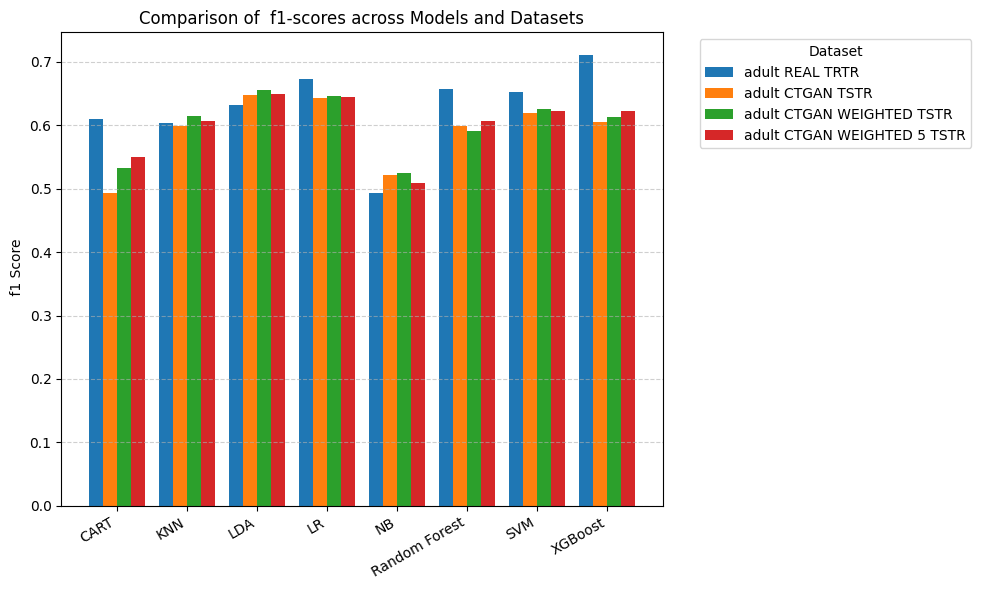

In [50]:
plot_score(dict_tstr_adult_ctgan_heom_any, score="f1_avg", score_name = " f1") 

## Privacy evaluation

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

def result_classification_plot(results, metric) :

    # your dictionary
    # Convert nested dict to DataFrame
    df = pd.concat(
        {outer: pd.DataFrame(inner).T for outer, inner in results.items()},
        axis=0
    )

    # Extract only Accuracy scores
    accuracy_df = df[metric].unstack(level=0)

    print(f"=== {metric} comparison table ===")
    print(accuracy_df)

    # Plot comparison for each PAY variable
    plt.figure(figsize=(10, 6))
    accuracy_df.plot(kind='bar', figsize=(10, 6))
    plt.title(f"{metric} comparison across datasets (AIA)")
    plt.ylabel(metric)
    plt.xlabel("PAY variable")
    plt.xticks(rotation=0)
    plt.legend(title="Dataset / Filter")
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



def plot_classification_results(results, metric_str) :
    # ---- Paste your dictionary here ----
    # results = {
    #     # ... your full nested dictionary ...
    # }

    # ---- Extract accuracy per epsilon ----
    records = []
    for eps, feats in results.items():
        for feat, metrics in feats.items():
            acc = metrics[metric_str]
            records.append({"epsilon": eps, "feature": feat, metric_str: acc})

    df = pd.DataFrame(records)

    # Remove non-numeric epsilon (like 'Real' or 'None') for the curve plot
    def to_float(x):
        try:
            return float(x)
        except:
            return np.nan

    df["eps_value"] = df["epsilon"].apply(to_float)
    df_numeric = df.dropna(subset=["eps_value"])

    # Compute mean and std across features per epsilon
    summary = (
        df_numeric.groupby("eps_value")[metric_str]
        .agg(["mean", "std"])
        .reset_index()
        .sort_values("eps_value")
    )

    # ---- Plot ----
    plt.figure(figsize=(9,6))

    # 1️⃣  Per-feature accuracy curves
    for feat in df_numeric["feature"].unique():
        sub = df_numeric[df_numeric["feature"] == feat].sort_values("eps_value")
        plt.plot(sub["eps_value"], sub[metric_str], marker='o', alpha=0.5, label=feat)

    # 2️⃣  Mean ± std envelope
    plt.plot(summary["eps_value"], summary["mean"], color='black', linewidth=2.5, label=f"Mean {metric_str}")
    plt.fill_between(
        summary["eps_value"],
        summary["mean"] - summary["std"],
        summary["mean"] + summary["std"],
        color='gray', alpha=0.2, label="±1 SD"
    )

    # 3️⃣  Formatting
    plt.xlabel(r"$\varepsilon_{\mathrm{ANY}}$")
    plt.ylabel(f"AIA {metric_str}")
    plt.title(f"Evolution of AIA {metric_str} vs ε (per feature and mean ± SD)")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()


### Privacy evaluation loader

In [15]:
dict_results_credit_ctgan_privacy  = {
    'credit REAL' : load_all_results(f'{PRIVACY_ONLY_DIR}/credit_ctgan_baseline').privacy_evaluation_results.classification_results()['real'],
    'credit CTGAN' : load_all_results(f'{PRIVACY_ONLY_DIR}/credit_ctgan_baseline').privacy_evaluation_results.classification_results()['synthetic'],
    'credit CTGAN V0' : load_all_results(f'{PRIVACY_ONLY_DIR}/credit_ctgan_eps_0.01').privacy_evaluation_results.classification_results()['synthetic'],
    'credit CTGAN V1' : load_all_results(f'{PRIVACY_ONLY_DIR_WEIGHTED}/credit_ctgan_eps_0.01_weighted').privacy_evaluation_results.classification_results()['synthetic'],   
    'credit CTGAN V2' : load_all_results(f'{PRIVACY_ONLY_DIR_WEIGHTED_5}/credit_ctgan_eps_0.01_weighted_5').privacy_evaluation_results.classification_results()['synthetic'],  
}

dict_results_credit_tvae_privacy  = {
    'credit REAL' : load_all_results(f'{PRIVACY_ONLY_DIR}/credit_tvae_baseline').privacy_evaluation_results.classification_results()['real'],
    'credit TVAE' : load_all_results(f'{PRIVACY_ONLY_DIR}/credit_tvae_baseline').privacy_evaluation_results.classification_results()['synthetic'],
    'credit TVAE V0' : load_all_results(f'{PRIVACY_ONLY_DIR}/credit_tvae_eps_0.01').privacy_evaluation_results.classification_results()['synthetic'],
    'credit TVAE V1' : load_all_results(f'{PRIVACY_ONLY_DIR_WEIGHTED}/credit_tvae_eps_0.01_weighted').privacy_evaluation_results.classification_results()['synthetic'],   
    'credit TVAE V2' : load_all_results(f'{PRIVACY_ONLY_DIR_WEIGHTED_5}/credit_tvae_eps_0.01_weighted_5').privacy_evaluation_results.classification_results()['synthetic'],  
}


dict_results_adult_ctgan_privacy  = {
    'adult REAL' : load_all_results(f'{PRIVACY_ONLY_DIR}/adult_ctgan_baseline').privacy_evaluation_results.classification_results()['real'],
    'adult CTGAN' : load_all_results(f'{PRIVACY_ONLY_DIR}/adult_ctgan_baseline').privacy_evaluation_results.classification_results()['synthetic'],
    'adult CTGAN V0' : load_all_results(f'{PRIVACY_ONLY_DIR}/adult_ctgan_eps_0.01').privacy_evaluation_results.classification_results()['synthetic'],
    'adult CTGAN V1' : load_all_results(f'{PRIVACY_ONLY_DIR_WEIGHTED}/adult_ctgan_eps_0.01_weighted').privacy_evaluation_results.classification_results()['synthetic'],   
    'adult CTGAN V2' : load_all_results(f'{PRIVACY_ONLY_DIR_WEIGHTED_5}/adult_ctgan_eps_0.01_weighted_5').privacy_evaluation_results.classification_results()['synthetic'],  
}

dict_results_adult_tvae_privacy  = {
    'adult REAL' : load_all_results(f'{PRIVACY_ONLY_DIR}/adult_tvae_baseline').privacy_evaluation_results.classification_results()['real'],
    'adult TVAE' : load_all_results(f'{PRIVACY_ONLY_DIR}/adult_tvae_baseline').privacy_evaluation_results.classification_results()['synthetic'],
    'adult TVAE V0' : load_all_results(f'{PRIVACY_ONLY_DIR}/adult_tvae_eps_0.01').privacy_evaluation_results.classification_results()['synthetic'],
    'adult TVAE V1' : load_all_results(f'{PRIVACY_ONLY_DIR_WEIGHTED}/adult_tvae_eps_0.01_weighted').privacy_evaluation_results.classification_results()['synthetic'],   
    'adult TVAE V2' : load_all_results(f'{PRIVACY_ONLY_DIR_WEIGHTED_5}/adult_tvae_eps_0.01_weighted_5').privacy_evaluation_results.classification_results()['synthetic'],  
}

dict_results_cardio_ctgan_privacy  = {
    'cardio REAL' : load_all_results(f'{PRIVACY_ONLY_DIR}/cardio_ctgan_baseline').privacy_evaluation_results.classification_results()['real'],
    'cardio CTGAN' : load_all_results(f'{PRIVACY_ONLY_DIR}/cardio_ctgan_baseline').privacy_evaluation_results.classification_results()['synthetic'],
    'cardio CTGAN V0' : load_all_results(f'{PRIVACY_ONLY_DIR}/cardio_ctgan_eps_0.01').privacy_evaluation_results.classification_results()['synthetic'],
    'cardio CTGAN V1' : load_all_results(f'{PRIVACY_ONLY_DIR_WEIGHTED}/cardio_ctgan_eps_0.01_weighted').privacy_evaluation_results.classification_results()['synthetic'],   
    'cardio CTGAN V2' : load_all_results(f'{PRIVACY_ONLY_DIR_WEIGHTED_5}/cardio_ctgan_eps_0.01_weighted_5').privacy_evaluation_results.classification_results()['synthetic'],  
}

dict_results_cardio_tvae_privacy  = {
    'cardio REAL' : load_all_results(f'{PRIVACY_ONLY_DIR}/cardio_tvae_baseline').privacy_evaluation_results.classification_results()['real'],
    'cardio TVAE' : load_all_results(f'{PRIVACY_ONLY_DIR}/cardio_tvae_baseline').privacy_evaluation_results.classification_results()['synthetic'],
    'cardio TVAE V0' : load_all_results(f'{PRIVACY_ONLY_DIR}/cardio_tvae_eps_0.01').privacy_evaluation_results.classification_results()['synthetic'],
    'cardio TVAE V1' : load_all_results(f'{PRIVACY_ONLY_DIR_WEIGHTED}/cardio_tvae_eps_0.01_weighted').privacy_evaluation_results.classification_results()['synthetic'],   
    'cardio TVAE V2' : load_all_results(f'{PRIVACY_ONLY_DIR_WEIGHTED_5}/cardio_tvae_eps_0.01_weighted_5').privacy_evaluation_results.classification_results()['synthetic'],  
}

classification = {
    'credit CTGAN' : dict_results_credit_ctgan_privacy,
    'credit TVAE' : dict_results_credit_tvae_privacy,
    'adult CTGAN' : dict_results_adult_ctgan_privacy,
    'adult TVAE' : dict_results_adult_tvae_privacy,
    'cardio CTGAN' : dict_results_cardio_ctgan_privacy,
    'cardio TVAE' : dict_results_cardio_tvae_privacy,
}


In [16]:
dict_results_credit_ctgan_privacy  = {
    'credit REAL' : load_all_results(f'{PRIVACY_ONLY_DIR}/credit_ctgan_baseline').privacy_evaluation_results.regression_results()['real'],
    'credit CTGAN' : load_all_results(f'{PRIVACY_ONLY_DIR}/credit_ctgan_baseline').privacy_evaluation_results.regression_results()['synthetic'],
    'credit CTGAN V0' : load_all_results(f'{PRIVACY_ONLY_DIR}/credit_ctgan_eps_0.01').privacy_evaluation_results.regression_results()['synthetic'],
    'credit CTGAN V1' : load_all_results(f'{PRIVACY_ONLY_DIR_WEIGHTED}/credit_ctgan_eps_0.01_weighted').privacy_evaluation_results.regression_results()['synthetic'],   
    'credit CTGAN V2' : load_all_results(f'{PRIVACY_ONLY_DIR_WEIGHTED_5}/credit_ctgan_eps_0.01_weighted_5').privacy_evaluation_results.regression_results()['synthetic'],  
}

dict_results_credit_tvae_privacy  = {
    'credit REAL' : load_all_results(f'{PRIVACY_ONLY_DIR}/credit_tvae_baseline').privacy_evaluation_results.regression_results()['real'],
    'credit TVAE' : load_all_results(f'{PRIVACY_ONLY_DIR}/credit_tvae_baseline').privacy_evaluation_results.regression_results()['synthetic'],
    'credit TVAE V0' : load_all_results(f'{PRIVACY_ONLY_DIR}/credit_tvae_eps_0.01').privacy_evaluation_results.regression_results()['synthetic'],
    'credit TVAE V1' : load_all_results(f'{PRIVACY_ONLY_DIR_WEIGHTED}/credit_tvae_eps_0.01_weighted').privacy_evaluation_results.regression_results()['synthetic'],   
    'credit TVAE V2' : load_all_results(f'{PRIVACY_ONLY_DIR_WEIGHTED_5}/credit_tvae_eps_0.01_weighted_5').privacy_evaluation_results.regression_results()['synthetic'],  
}


dict_results_adult_ctgan_privacy  = {
    'adult REAL' : load_all_results(f'{PRIVACY_ONLY_DIR}/adult_ctgan_baseline').privacy_evaluation_results.regression_results()['real'],
    'adult CTGAN' : load_all_results(f'{PRIVACY_ONLY_DIR}/adult_ctgan_baseline').privacy_evaluation_results.regression_results()['synthetic'],
    'adult CTGAN V0' : load_all_results(f'{PRIVACY_ONLY_DIR}/adult_ctgan_eps_0.01').privacy_evaluation_results.regression_results()['synthetic'],
    'adult CTGAN V1' : load_all_results(f'{PRIVACY_ONLY_DIR_WEIGHTED}/adult_ctgan_eps_0.01_weighted').privacy_evaluation_results.regression_results()['synthetic'],   
    'adult CTGAN V2' : load_all_results(f'{PRIVACY_ONLY_DIR_WEIGHTED_5}/adult_ctgan_eps_0.01_weighted_5').privacy_evaluation_results.regression_results()['synthetic'],  
}

dict_results_adult_tvae_privacy  = {
    'adult REAL' : load_all_results(f'{PRIVACY_ONLY_DIR}/adult_tvae_baseline').privacy_evaluation_results.regression_results()['real'],
    'adult TVAE' : load_all_results(f'{PRIVACY_ONLY_DIR}/adult_tvae_baseline').privacy_evaluation_results.regression_results()['synthetic'],
    'adult TVAE V0' : load_all_results(f'{PRIVACY_ONLY_DIR}/adult_tvae_eps_0.01').privacy_evaluation_results.regression_results()['synthetic'],
    'adult TVAE V1' : load_all_results(f'{PRIVACY_ONLY_DIR_WEIGHTED}/adult_tvae_eps_0.01_weighted').privacy_evaluation_results.regression_results()['synthetic'],   
    'adult TVAE V2' : load_all_results(f'{PRIVACY_ONLY_DIR_WEIGHTED_5}/adult_tvae_eps_0.01_weighted_5').privacy_evaluation_results.regression_results()['synthetic'],  
}

dict_results_cardio_ctgan_privacy  = {
    'cardio REAL' : load_all_results(f'{PRIVACY_ONLY_DIR}/cardio_ctgan_baseline').privacy_evaluation_results.regression_results()['real'],
    'cardio CTGAN' : load_all_results(f'{PRIVACY_ONLY_DIR}/cardio_ctgan_baseline').privacy_evaluation_results.regression_results()['synthetic'],
    'cardio CTGAN V0' : load_all_results(f'{PRIVACY_ONLY_DIR}/cardio_ctgan_eps_0.01').privacy_evaluation_results.regression_results()['synthetic'],
    'cardio CTGAN V1' : load_all_results(f'{PRIVACY_ONLY_DIR_WEIGHTED}/cardio_ctgan_eps_0.01_weighted').privacy_evaluation_results.regression_results()['synthetic'],   
    'cardio CTGAN V2' : load_all_results(f'{PRIVACY_ONLY_DIR_WEIGHTED_5}/cardio_ctgan_eps_0.01_weighted_5').privacy_evaluation_results.regression_results()['synthetic'],  
}

dict_results_cardio_tvae_privacy  = {
    'cardio REAL' : load_all_results(f'{PRIVACY_ONLY_DIR}/cardio_tvae_baseline').privacy_evaluation_results.regression_results()['real'],
    'cardio TVAE' : load_all_results(f'{PRIVACY_ONLY_DIR}/cardio_tvae_baseline').privacy_evaluation_results.regression_results()['synthetic'],
    'cardio TVAE V0' : load_all_results(f'{PRIVACY_ONLY_DIR}/cardio_tvae_eps_0.01').privacy_evaluation_results.regression_results()['synthetic'],
    'cardio TVAE V1' : load_all_results(f'{PRIVACY_ONLY_DIR_WEIGHTED}/cardio_tvae_eps_0.01_weighted').privacy_evaluation_results.regression_results()['synthetic'],   
    'cardio TVAE V2' : load_all_results(f'{PRIVACY_ONLY_DIR_WEIGHTED_5}/cardio_tvae_eps_0.01_weighted_5').privacy_evaluation_results.regression_results()['synthetic'],  
}

regression = {
    'credit CTGAN' : dict_results_credit_ctgan_privacy,
    'credit TVAE' : dict_results_credit_tvae_privacy,
    'adult CTGAN' : dict_results_adult_ctgan_privacy,
    'adult TVAE' : dict_results_adult_tvae_privacy,
    'cardio CTGAN' : dict_results_cardio_ctgan_privacy,
    'cardio TVAE' : dict_results_cardio_tvae_privacy,
}


In [31]:
regression

{'credit CTGAN': {'credit REAL': {'BILL_AMT1': {'MSE': 5468560460.573229,
    'R2': 0.01621769981496146,
    'RMSE': 73949.71575721727},
   'BILL_AMT2': {'MSE': 5132743136.9349,
    'R2': 0.014176928287188417,
    'RMSE': 71643.16531906516},
   'BILL_AMT3': {'MSE': 4788066708.717484,
    'R2': 0.013741929467227854,
    'RMSE': 69195.85759796236},
   'BILL_AMT4': {'MSE': 4218445630.335808,
    'R2': 0.012705184965194571,
    'RMSE': 64949.562202803245},
   'BILL_AMT5': {'MSE': 3731757027.2485213,
    'R2': 0.011221405321673594,
    'RMSE': 61088.108722144294},
   'BILL_AMT6': {'MSE': 3635375526.4253736,
    'R2': 0.010998306581029405,
    'RMSE': 60294.07538411526},
   'LIMIT_BAL': {'MSE': 13859789419.016233,
    'R2': 0.177280470742322,
    'RMSE': 117727.60686863652},
   'PAY_AMT1': {'MSE': 203456265.01192343,
    'R2': 0.0036720396670297806,
    'RMSE': 14263.809624778489},
   'PAY_AMT2': {'MSE': 295229416.4768639,
    'R2': 0.0009580589619399005,
    'RMSE': 17182.24131121618},
   '

,dataset,generator,setting,Accuracy,weighted_F1
0,adult,CTGAN,V0,0.809440,0.807149
1,adult,CTGAN,V1,0.805080,0.802088
2,adult,CTGAN,V2,0.820588,0.810853
3,adult,CTGAN,no_filter,0.816903,0.809163
4,adult,REAL,REAL,0.844604,0.826499
5,adult,TVAE,V0,0.819299,0.808263
6,adult,TVAE,V1,0.830662,0.815358
7,adult,TVAE,V2,0.833425,0.816002
8,adult,TVAE,no_filter,0.841687,0.821401
9,cardio,CTGAN,V0,0.696198,0.713817


,dataset,generator,setting,R2,RMSE
0,adult,CTGAN,V0,0.030444,2648.363183
1,adult,CTGAN,V1,0.052722,2642.525451
2,adult,CTGAN,V2,0.056235,2642.457337
3,adult,CTGAN,no_filter,0.050937,2647.313786
4,adult,REAL,REAL,0.088270,2594.217388
5,adult,TVAE,V0,0.011761,2672.861125
6,adult,TVAE,V1,0.038493,2668.797748
7,adult,TVAE,V2,0.034261,2668.403764
8,adult,TVAE,no_filter,0.036552,2674.862176
9,cardio,CTGAN,V0,-0.000205,157.433732


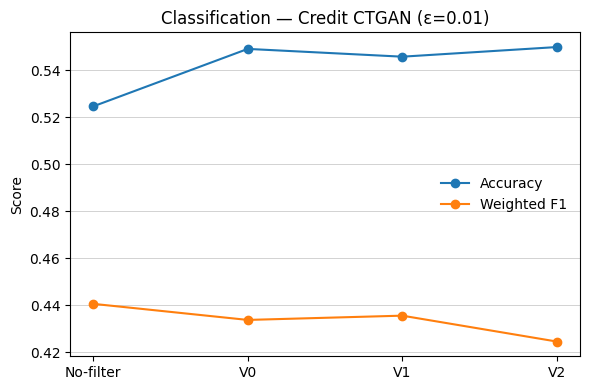

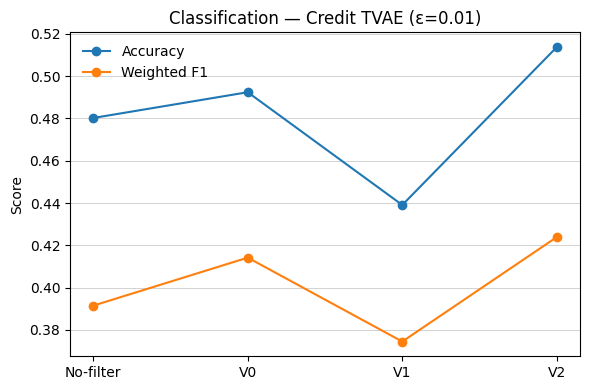

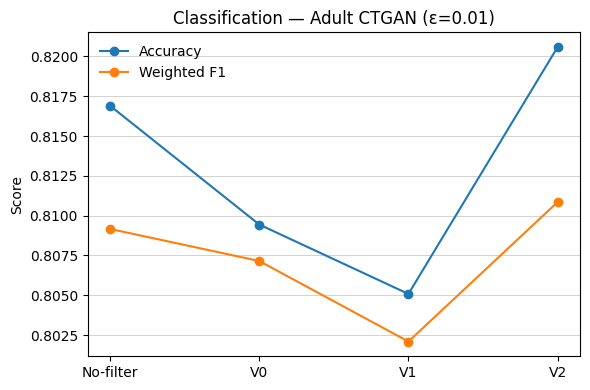

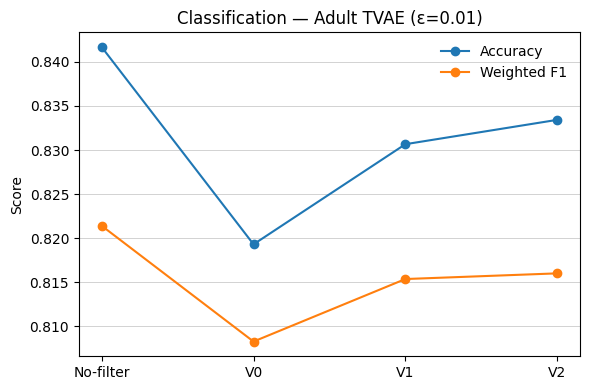

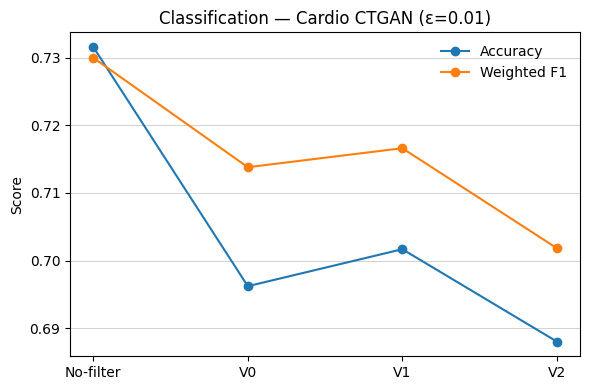

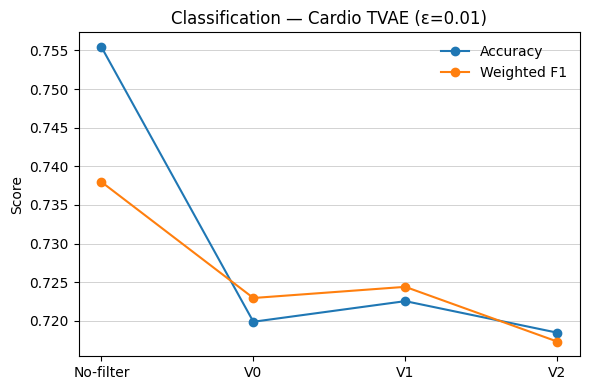

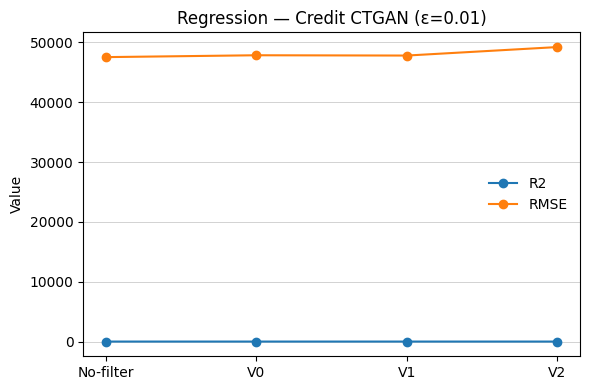

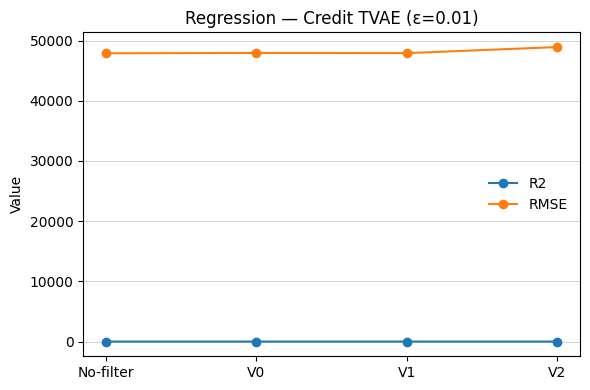

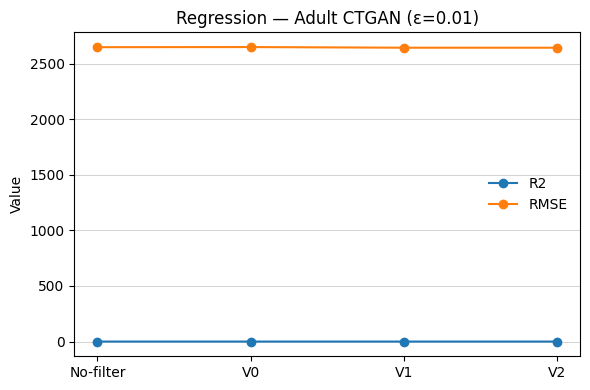

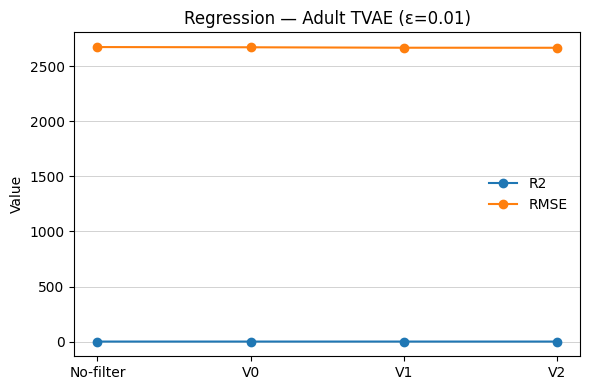

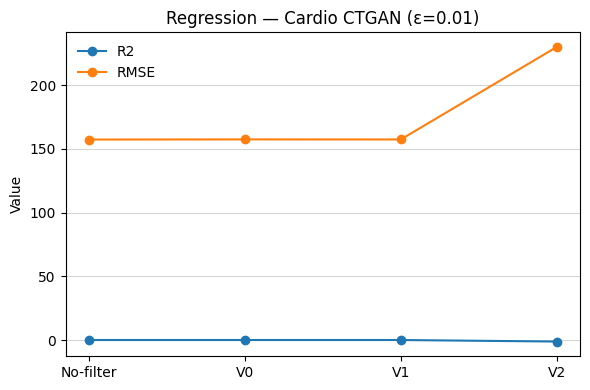

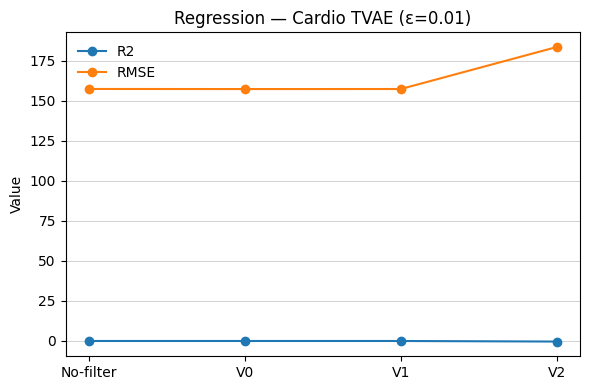

,dataset,generator,setting,Accuracy,weighted_F1
0,adult,CTGAN,V0,-0.007463,-0.002014
1,adult,CTGAN,V1,-0.011824,-0.007075
2,adult,CTGAN,V2,0.003685,0.001690
3,adult,TVAE,V0,-0.022388,-0.013139
4,adult,TVAE,V1,-0.011025,-0.006043
5,adult,TVAE,V2,-0.008261,-0.005399
6,cardio,CTGAN,V0,-0.035413,-0.016204
7,cardio,CTGAN,V1,-0.029937,-0.013389
8,cardio,CTGAN,V2,-0.043611,-0.028191
9,cardio,TVAE,V0,-0.035532,-0.015011


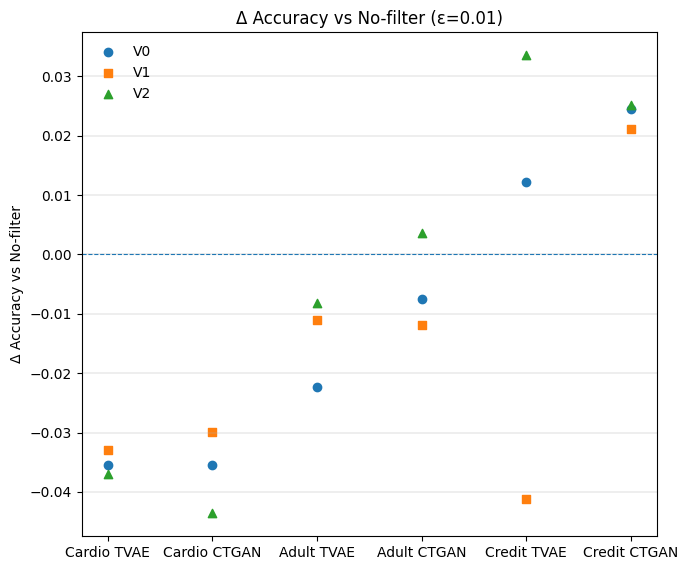

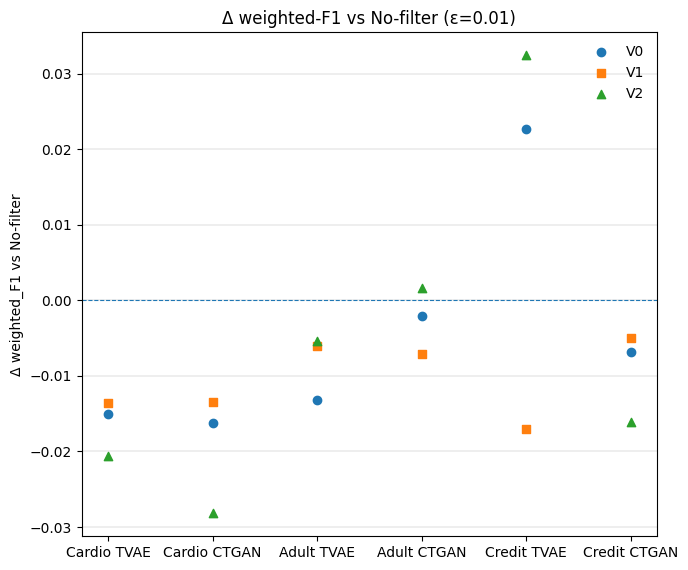

,dataset,generator,setting,R2,RMSE
0,adult,CTGAN,V0,-0.020492,1.049397
1,adult,CTGAN,V1,0.001785,-4.788335
2,adult,CTGAN,V2,0.005298,-4.856449
3,adult,TVAE,V0,-0.024791,-2.001051
4,adult,TVAE,V1,0.001941,-6.064428
5,adult,TVAE,V2,-0.002291,-6.458412
6,cardio,CTGAN,V0,-0.001259,0.107027
7,cardio,CTGAN,V1,-0.000639,0.053528
8,cardio,CTGAN,V2,-1.206682,72.577086
9,cardio,TVAE,V0,0.000634,-0.054498


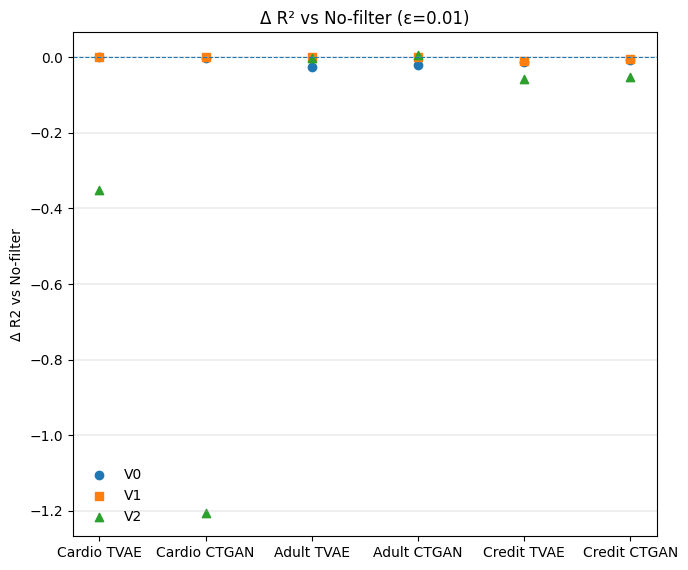

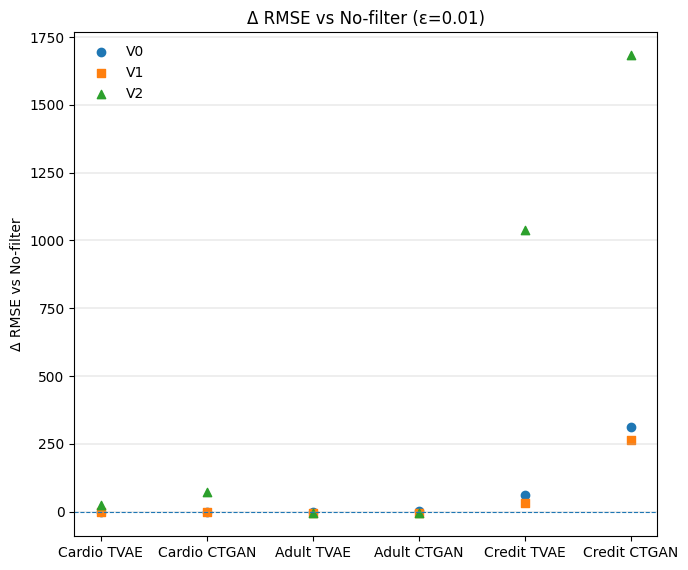


% ====== LaTeX tables (Classification) ======
\begin{table}[t]
\centering
\small
\caption{AIA (Classification) on \textit{Credit} with \textbf{CTGAN} at fixed $\varepsilon_{\mathrm{ANY}}=0.01$. Scores averaged over sensitive attributes. $\Delta$ vs \textit{No-filter}.}
\label{tab:aia_cls_credit_CTGAN}
\begin{tabular}{lrr@{\,}lr@{\,}l}
\toprule
Setting & Accuracy & Weighted F1 & $\Delta$ Accuracy & $\Delta$ Weighted F1 \\
\midrule
Real & 0.564 & 0.439 & -- & -- \\
No-filter & 0.525 & 0.441 & +0.000 & +0.000 \\
V0 & 0.549 & 0.434 & +0.024 & -0.007 \\
V1 & 0.546 & 0.436 & +0.021 & -0.005 \\
V2 & 0.550 & 0.425 & +0.025 & -0.016 \\
\bottomrule
\end{tabular}
\end{table} 

\begin{table}[t]
\centering
\small
\caption{AIA (Classification) on \textit{Credit} with \textbf{TVAE} at fixed $\varepsilon_{\mathrm{ANY}}=0.01$. Scores averaged over sensitive attributes. $\Delta$ vs \textit{No-filter}.}
\label{tab:aia_cls_credit_TVAE}
\begin{tabular}{lrr@{\,}lr@{\,}l}
\toprule
Setting & Accuracy & Weigh

In [14]:
# ================== AIA inline plots + LaTeX tables (handles extra nesting) ==================
# Works with your variables: `classifications` and `regressions`.
# matplotlib only; one chart per figure; no explicit colors; ε_ANY = 0.01 fixed.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# --- map to expected names
if 'classification' not in globals():
    if 'classifications' in globals():
        classification = classifications
    else:
        raise NameError("Please define `classifications` (your big dict of classification results).")
if 'regression' not in globals():
    if 'regressions' in globals():
        regression = regressions
    else:
        regression = {}  # optional

CASES = [
    ("credit", "CTGAN"),
    ("credit", "TVAE"),
    ("adult",  "CTGAN"),
    ("adult",  "TVAE"),
    ("cardio", "CTGAN"),
    ("cardio", "TVAE"),
]

# ------------------ helpers ------------------
def _split_top_key(k: str):
    parts = k.split()
    ds = parts[0] if parts else ""
    gen = parts[1] if len(parts) > 1 else ""
    return ds, gen

def _detect_setting(k: str) -> str:
    if k.endswith(" V0"): return "V0"
    if k.endswith(" V1"): return "V1"
    if k.endswith(" V2"): return "V2"
    parts = k.split()
    if len(parts) > 1 and parts[1] == "REAL": return "REAL"
    return "no_filter"

def _to_rows_extra_nested(block: dict, task: str):
    """
    Correctly read setting from the INNER (mid) key, e.g.:
      top_key='credit CTGAN'
        └─ mid_key ∈ {'credit REAL', 'credit CTGAN', 'credit CTGAN V0', 'credit CTGAN V1', 'credit CTGAN V2'}
             └─ attribute -> metrics
    """
    rows = []
    for _outer_key, inner in block.items():
        if not isinstance(inner, dict):
            continue
        for mid_key, attr_map in inner.items():
            if not isinstance(attr_map, dict):
                continue
            ds, gen = _split_top_key(mid_key)          # <-- take ds/gen from INNER key
            st       = _detect_setting(mid_key)        # <-- take setting from INNER key
            for attr, metrics in attr_map.items():
                if not isinstance(metrics, dict):
                    continue
                if task == "classification":
                    if ("Accuracy" in metrics) and ("weighted F1" in metrics):
                        rows.append({
                            "dataset": ds, "generator": gen, "setting": st, "attribute": attr,
                            "Accuracy": float(metrics["Accuracy"]),
                            "weighted_F1": float(metrics["weighted F1"]),
                        })
                else:  # regression
                    if ("R2" in metrics) and ("RMSE" in metrics):
                        rows.append({
                            "dataset": ds, "generator": gen, "setting": st, "attribute": attr,
                            "R2": float(metrics["R2"]), "RMSE": float(metrics["RMSE"]),
                        })
    return rows


def _summarize(df: pd.DataFrame, task: str) -> pd.DataFrame:
    if df.empty: 
        return df
    cols = ["Accuracy","weighted_F1"] if task=="classification" else ["R2","RMSE"]
    cols = [c for c in cols if c in df.columns]
    return df.groupby(["dataset","generator","setting"], as_index=False)[cols].mean()

def _settings_in_order(df_case: pd.DataFrame):
    order = ["no_filter","V0","V1","V2"]
    return [s for s in order if s in set(df_case["setting"])]

def _plot_series_inline(xlabels, series_dict, title, ylabel):
    plt.figure(figsize=(6,4))
    xs = np.arange(len(xlabels))
    for label, y in series_dict.items():
        plt.plot(xs, y, marker="o", label=label)
    plt.xticks(xs, xlabels, rotation=0)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, axis="y", linewidth=0.4)
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

def _compute_deltas(sum_df: pd.DataFrame, metrics):
    rows = []
    for (ds, gen), grp in sum_df.groupby(["dataset","generator"]):
        if "no_filter" not in set(grp["setting"]): 
            continue
        ref = grp[grp["setting"]=="no_filter"].iloc[0]
        for setting in ["V0","V1","V2"]:
            if setting not in set(grp["setting"]):
                continue
            cur = grp[grp["setting"]==setting].iloc[0]
            row = {"dataset": ds, "generator": gen, "setting": setting}
            for m in metrics:
                if m in grp.columns:
                    row[m] = float(cur[m]) - float(ref[m])
            rows.append(row)
    return pd.DataFrame(rows)

def _forest_plot_inline(df_delta: pd.DataFrame, metric: str, title: str):
    if df_delta.empty or metric not in df_delta.columns:
        print(f"[warn] No data for forest plot metric={metric}")
        return

    df = df_delta.copy()
    df["case"] = df["dataset"].str.title() + " " + df["generator"]

    order = [f"{ds.title()} {gen}" for ds, gen in CASES if f"{ds.title()} {gen}" in set(df["case"])]
    df["case"] = pd.Categorical(df["case"], categories=order, ordered=True)
    df = df.sort_values(["case", "setting"])

    plt.figure(figsize=(7, 4 + 0.3 * len(order)))

    x_positions = {case: i for i, case in enumerate(order)}

    for setting, marker in zip(["V0", "V1", "V2"], ["o", "s", "^"]):
        sub = df[df["setting"] == setting]
        if sub.empty:
            continue

        xs = [x_positions[c] for c in sub["case"]]
        ys = sub[metric].values
        plt.scatter(xs, ys, marker=marker, label=setting)

    plt.xticks(range(len(order)), order)
    plt.axhline(0.0, linestyle="--", linewidth=0.8)
    plt.ylabel(f"Δ {metric} vs No-filter")
    plt.title(title)
    plt.grid(True, axis="y", linewidth=0.3)
    plt.legend(frameon=False)

    ax = plt.gca()
    ax.invert_xaxis()   # optional: reverse case order
    # ax.invert_yaxis() # ❌ remove this

    plt.tight_layout()
    plt.show()



def _latex_table_case(raw_df: pd.DataFrame, ds: str, gen: str, task: str) -> str:
    if task == "classification":
        m1, m2 = "Accuracy", "weighted_F1"
        m1_label, m2_label = "Accuracy", "Weighted F1"
        note = "Scores averaged over sensitive attributes."
    else:
        m1, m2 = "R2", "RMSE"
        m1_label, m2_label = "$R^2$", "RMSE"
        note = "Values averaged over targets (if multiple)."
    def avg(ds, gen, setting):
        tmp = raw_df[(raw_df["dataset"]==ds)&(raw_df["generator"]==gen)&(raw_df["setting"]==setting)]
        if tmp.empty: return None
        return float(tmp[m1].mean()), float(tmp[m2].mean())
    nof = avg(ds, gen, "no_filter")
    if nof is None: 
        return f"% No baseline for {ds} {gen} ({task})."
    rows = []
    real = avg(ds, "REAL", "REAL")
    if real is not None:
        rows.append(("Real", real[0], real[1], None, None))
    rows.append(("No-filter", nof[0], nof[1], 0.0, 0.0))
    for s in ["V0","V1","V2"]:
        val = avg(ds, gen, s)
        if val is None: continue
        rows.append((s, val[0], val[1], val[0]-nof[0], val[1]-nof[1]))
    caption = (f"AIA ({'Classification' if task=='classification' else 'Regression'}) on "
               f"\\textit{{{ds.title()}}} with \\textbf{{{gen}}} at fixed "
               f"$\\varepsilon_{{\\mathrm{{ANY}}}}=0.01$. {note} $\\Delta$ vs \\textit{{No-filter}}.")
    label = f"tab:aia_{'cls' if task=='classification' else 'reg'}_{ds}_{gen}".replace(" ","_")
    lines = []
    lines.append("\\begin{table}[t]")
    lines.append("\\centering")
    lines.append("\\small")
    lines.append(f"\\caption{{{caption}}}")
    lines.append(f"\\label{{{label}}}")
    lines.append("\\begin{tabular}{lrr@{\\,}lr@{\\,}l}")
    lines.append("\\toprule")
    lines.append(f"Setting & {m1_label} & {m2_label} & $\\Delta$ {m1_label} & $\\Delta$ {m2_label} \\\\")
    lines.append("\\midrule")
    for name, v1, v2, d1, d2 in rows:
        if d1 is None:
            lines.append(f"{name} & {v1:.3f} & {v2:.3f} & -- & -- \\\\")
        else:
            lines.append(f"{name} & {v1:.3f} & {v2:.3f} & {d1:+.3f} & {d2:+.3f} \\\\")
    lines.append("\\bottomrule")
    lines.append("\\end{tabular}")
    lines.append("\\end{table}")
    return "\n".join(lines)

# ------------------ 1) Build tidy frames (with extra nesting) ------------------
clf_rows = _to_rows_extra_nested(classification, task="classification")
df_clf = pd.DataFrame(clf_rows)
if df_clf.empty:
    raise ValueError("Parsed 0 rows from `classifications`. The parser now expects the extra nesting level you have.")

sum_clf = _summarize(df_clf, "classification")
display(sum_clf.sort_values(['dataset','generator','setting']).reset_index(drop=True))

df_reg = pd.DataFrame()
sum_reg = pd.DataFrame()
if regression:
    reg_rows = _to_rows_extra_nested(regression, task="regression")
    df_reg = pd.DataFrame(reg_rows)
    if not df_reg.empty:
        sum_reg = _summarize(df_reg, "regression")
        display(sum_reg.sort_values(['dataset','generator','setting']).reset_index(drop=True))
    else:
        print("ℹ️ `regressions` provided but had no rows with both 'R2' and 'RMSE' (skipped).")

# ------------------ 2) Option A: Panels (inline) ------------------
# Classification
for ds, gen in CASES:
    sub = sum_clf[(sum_clf["dataset"]==ds)&(sum_clf["generator"]==gen)]
    if sub.empty:
        continue
    order = _settings_in_order(sub)
    if not order:
        continue
    sub = sub.set_index("setting").loc[order]
    xlabels = ["No-filter","V0","V1","V2"][:len(order)]
    series = {"Accuracy": list(sub["Accuracy"].values),
              "Weighted F1": list(sub["weighted_F1"].values)}
    _plot_series_inline(xlabels, series, f"Classification — {ds.title()} {gen} (ε=0.01)", "Score")

# Regression
if not sum_reg.empty:
    for ds, gen in CASES:
        sub = sum_reg[(sum_reg["dataset"]==ds)&(sum_reg["generator"]==gen)]
        if sub.empty:
            continue
        order = _settings_in_order(sub)
        if not order:
            continue
        sub = sub.set_index("setting").loc[order]
        xlabels = ["No-filter","V0","V1","V2"][:len(order)]
        series = {}
        if "R2" in sub.columns:   series["R2"] = list(sub["R2"].values)
        if "RMSE" in sub.columns: series["RMSE"] = list(sub["RMSE"].values)
        if series:
            _plot_series_inline(xlabels, series, f"Regression — {ds.title()} {gen} (ε=0.01)", "Value")

# ------------------ 3) Option B: Forest-of-Δ (inline) ------------------
delta_clf = _compute_deltas(sum_clf, ["Accuracy","weighted_F1"])
if not delta_clf.empty:
    display(delta_clf.sort_values(['dataset','generator','setting']).reset_index(drop=True))
    _forest_plot_inline(delta_clf, "Accuracy",     "Δ Accuracy vs No-filter (ε=0.01)")
    _forest_plot_inline(delta_clf, "weighted_F1", "Δ weighted-F1 vs No-filter (ε=0.01)")

if not sum_reg.empty:
    delta_reg = _compute_deltas(sum_reg, ["R2","RMSE"])
    if not delta_reg.empty:
        display(delta_reg.sort_values(['dataset','generator','setting']).reset_index(drop=True))
        _forest_plot_inline(delta_reg, "R2",   "Δ R² vs No-filter (ε=0.01)")
        _forest_plot_inline(delta_reg, "RMSE", "Δ RMSE vs No-filter (ε=0.01)")

# ------------------ 4) Option C: LaTeX tables (printed) ------------------
print("\n% ====== LaTeX tables (Classification) ======")
for ds, gen in CASES:
    print(_latex_table_case(df_clf, ds, gen, "classification"), "\n")

if not df_reg.empty:
    print("\n% ====== LaTeX tables (Regression) ======")
    for ds, gen in CASES:
        print(_latex_table_case(df_reg, ds, gen, "regression"), "\n")
# ==============================================================================


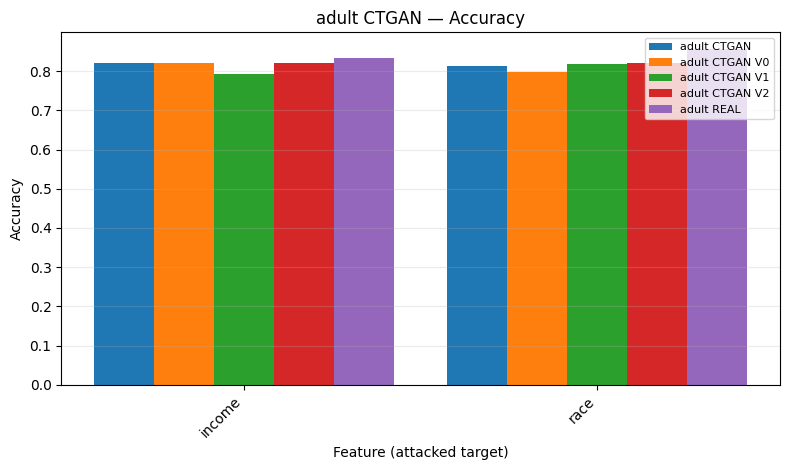

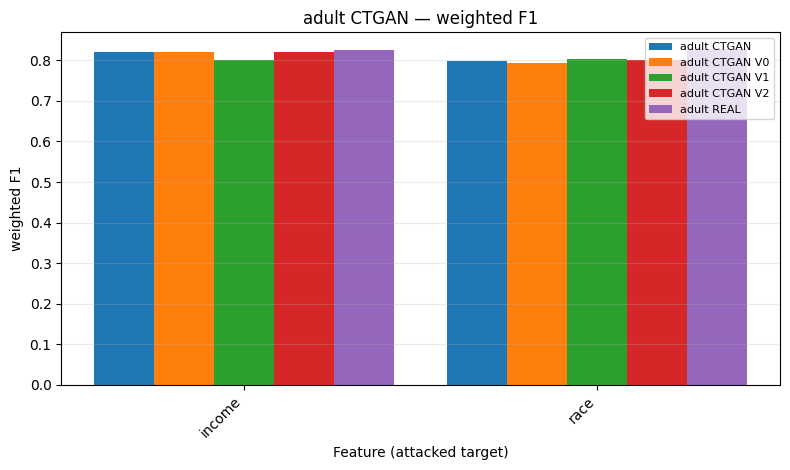

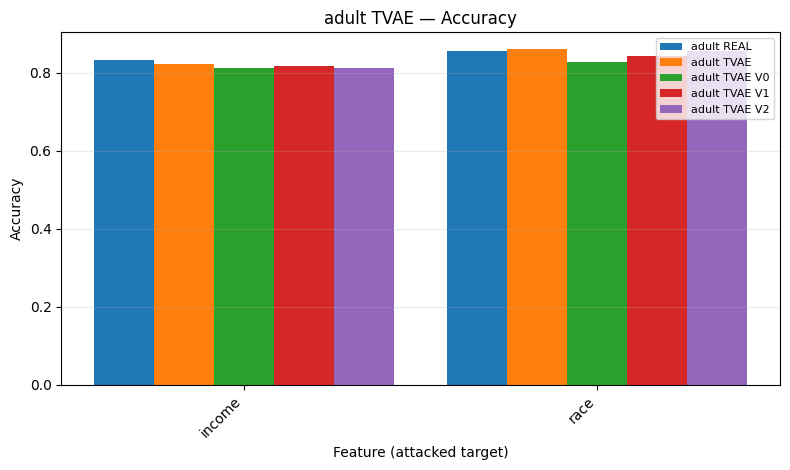

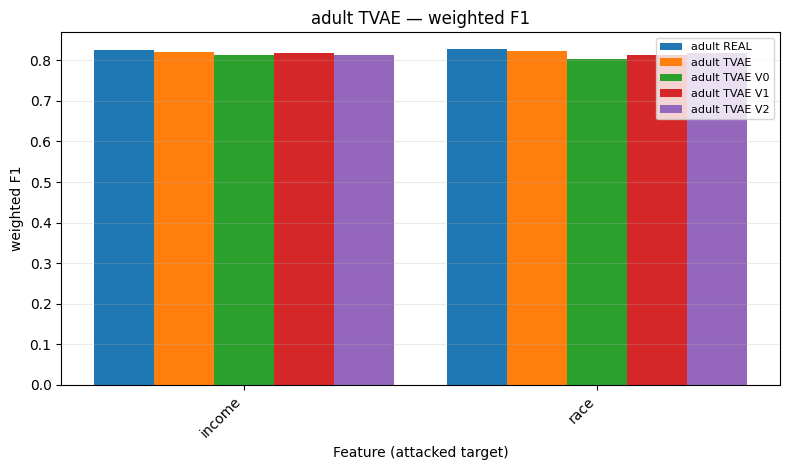

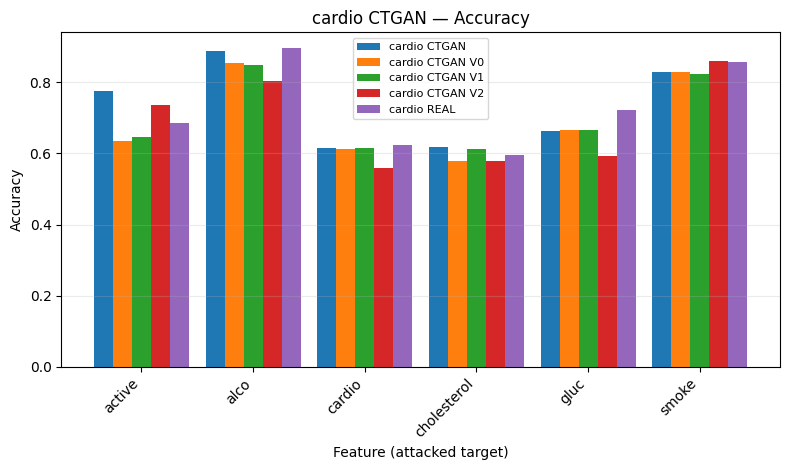

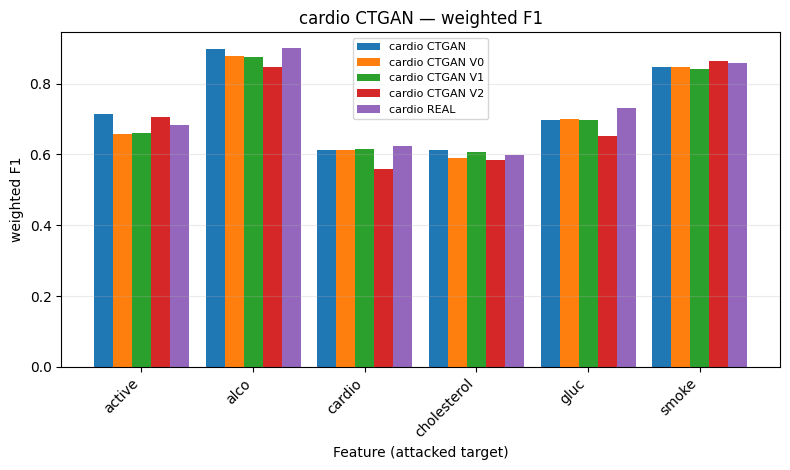

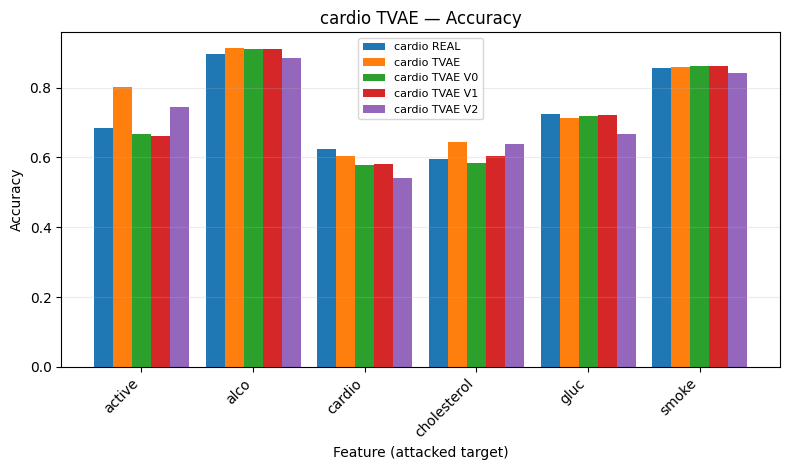

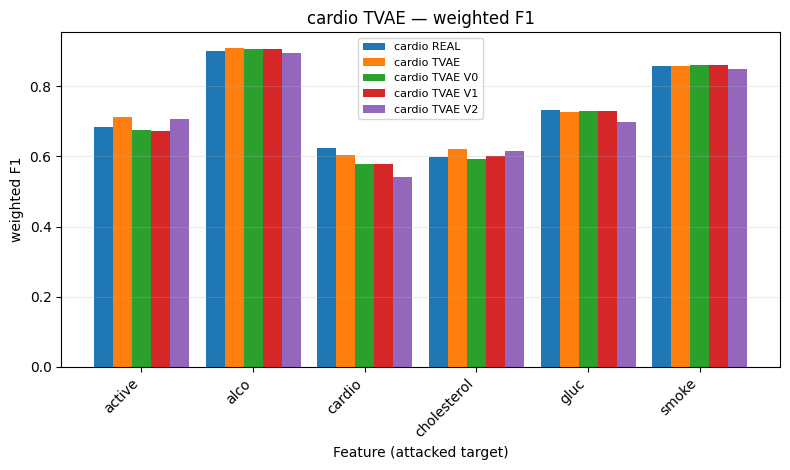

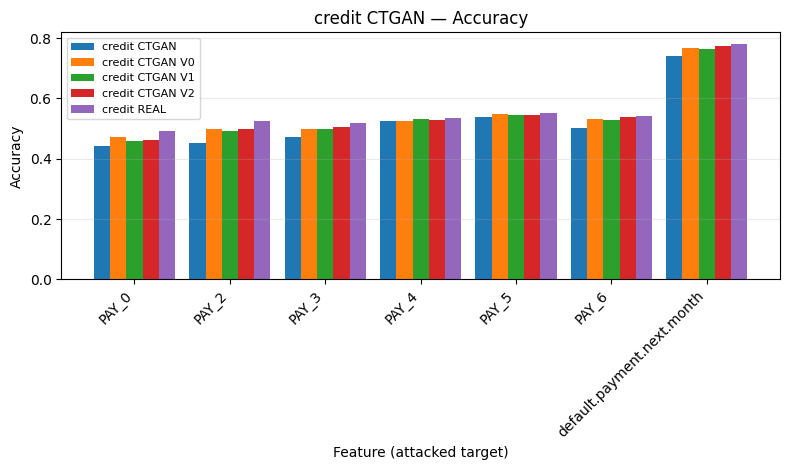

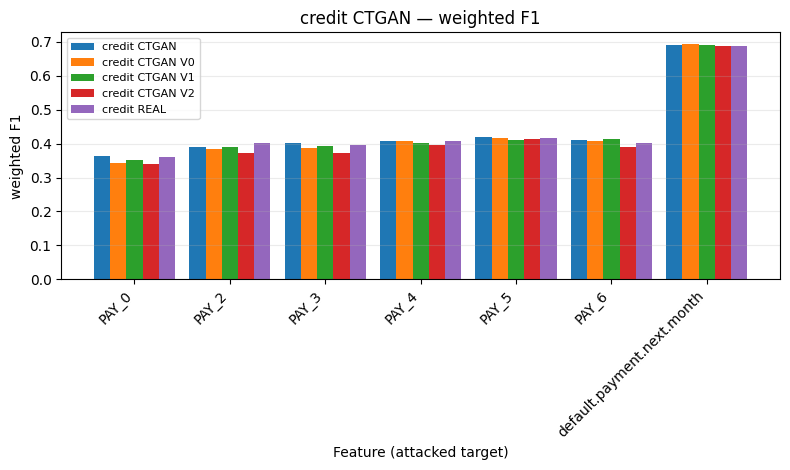

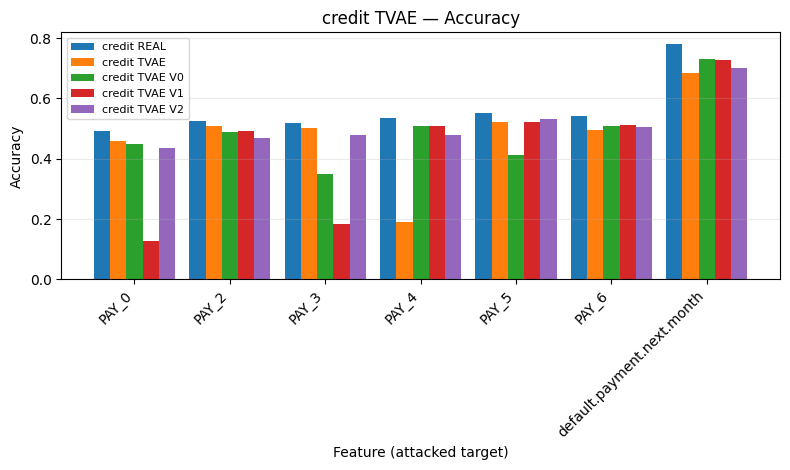

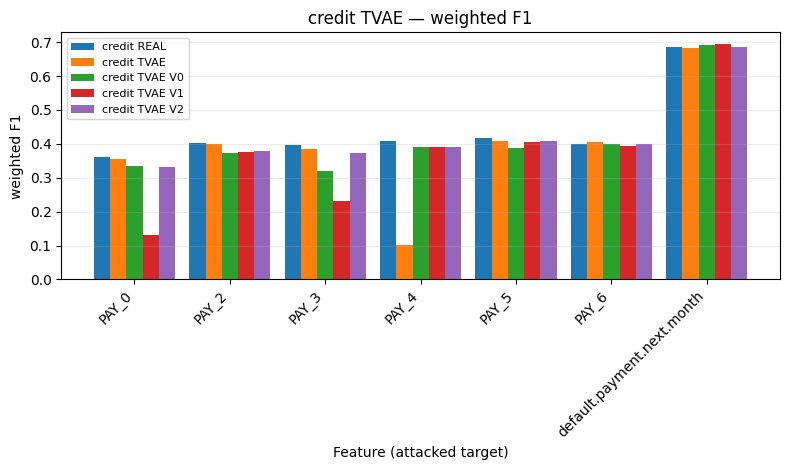

,group,variant,target,metric,value
0,credit CTGAN,credit REAL,PAY_0,Accuracy,0.491833
3,credit CTGAN,credit REAL,PAY_0,weighted F1,0.360621
6,credit CTGAN,credit REAL,PAY_2,Accuracy,0.524333
9,credit CTGAN,credit REAL,PAY_2,weighted F1,0.401876
12,credit CTGAN,credit REAL,PAY_3,Accuracy,0.519500
...,...,...,...,...,...
885,cardio TVAE,cardio TVAE V2,cholesterol,weighted F1,0.614243
888,cardio TVAE,cardio TVAE V2,gluc,Accuracy,0.665857
891,cardio TVAE,cardio TVAE V2,gluc,weighted F1,0.699416
894,cardio TVAE,cardio TVAE V2,smoke,Accuracy,0.840476


In [30]:
from __future__ import annotations

from pathlib import Path
from typing import Any, Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def flatten_aia_dict(d: Dict[str, Any]) -> pd.DataFrame:
    rows: List[dict] = []
    for group, group_payload in d.items():
        if not isinstance(group_payload, dict):
            continue
        for variant, variant_payload in group_payload.items():
            if not isinstance(variant_payload, dict):
                continue
            for target, metrics_payload in variant_payload.items():
                if not isinstance(metrics_payload, dict):
                    continue
                for metric, value in metrics_payload.items():
                    if value is None:
                        continue
                    try:
                        v = float(value)
                    except Exception:
                        continue
                    rows.append(
                        {
                            "group": str(group),      # e.g., "credit CTGAN"
                            "variant": str(variant),  # e.g., "credit CTGAN V1" or "credit REAL"
                            "target": str(target),    # feature attacked
                            "metric": str(metric),    # e.g., "Accuracy"
                            "value": v,
                        }
                    )
    return pd.DataFrame(rows)


def plot_feature_bars(
    d: Dict[str, Any],
    metrics: List[str] | None = None,
    include_real: bool = True,
    variant_order: List[str] | None = None,
    rotate_xticks: int = 45,
    save_dir: str | Path | None = None,
) -> pd.DataFrame:
    """
    One figure per (group, metric).
    X = target/feature, Y = score, grouped bars = variants.

    If variant_order is provided, variants are shown in that order (when present).
    Otherwise, they appear in sorted order.
    """
    df = flatten_aia_dict(d)
    if df.empty:
        raise ValueError("No plottable numeric values found in the provided dict.")

    if not include_real:
        df = df[~df["variant"].str.contains(r"\bREAL\b", regex=True)].copy()

    if metrics is not None:
        df = df[df["metric"].isin(metrics)].copy()

    out_dir = Path(save_dir) if save_dir is not None else None
    if out_dir is not None:
        out_dir.mkdir(parents=True, exist_ok=True)

    for group in sorted(df["group"].unique()):
        dfg = df[df["group"] == group]
        for metric in sorted(dfg["metric"].unique()):
            dfm = dfg[dfg["metric"] == metric].copy()

            # pivot: rows=targets, cols=variants, values=scores
            pivot = (
                dfm.pivot_table(index="target", columns="variant", values="value", aggfunc="mean")
                .sort_index()
            )

            # order variants if requested
            cols = list(pivot.columns)
            if variant_order is not None:
                ordered = [v for v in variant_order if v in cols]
                remaining = [v for v in cols if v not in ordered]
                pivot = pivot[ordered + sorted(remaining)]
            else:
                pivot = pivot[sorted(cols)]

            targets = list(pivot.index)
            variants = list(pivot.columns)

            x = np.arange(len(targets))
            n = max(1, len(variants))
            width = min(0.85 / n, 0.22)  # keep bars readable

            fig_w = max(8.0, 0.55 * len(targets))
            fig_h = 4.8
            plt.figure(figsize=(fig_w, fig_h))

            for i, v in enumerate(variants):
                y = pivot[v].to_numpy(dtype=float)
                # centered grouped bars
                offset = (i - (n - 1) / 2) * width
                plt.bar(x + offset, y, width=width, label=v)

            plt.title(f"{group} — {metric}")
            plt.xlabel("Feature (attacked target)")
            plt.ylabel(metric)

            plt.xticks(x, targets, rotation=rotate_xticks, ha="right")
            plt.grid(True, which="major", axis="y", alpha=0.25)
            plt.legend(fontsize=8)
            plt.tight_layout()

            if out_dir is not None:
                fname = f"{group}__{metric}".replace("/", "_").replace(" ", "_") + ".png"
                plt.savefig(out_dir / fname, dpi=200)

            plt.show()

    return df


# -------------------------
# Usage
# -------------------------
# results = <your big dict>
plot_feature_bars(classification, metrics=["Accuracy", "weighted F1"], include_real=True)
#
# Optional save:
# plot_feature_bars(results, save_dir="aia_feature_bars")


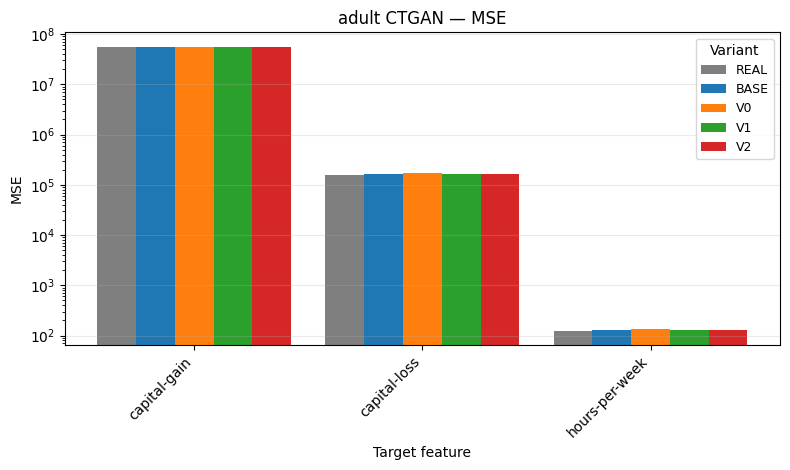

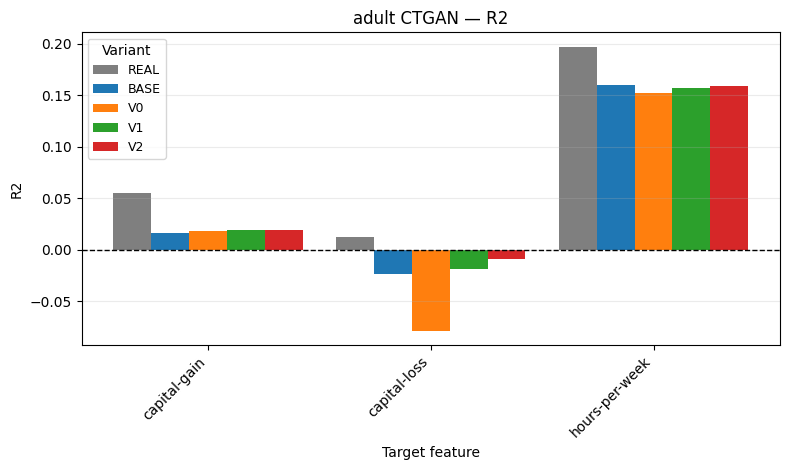

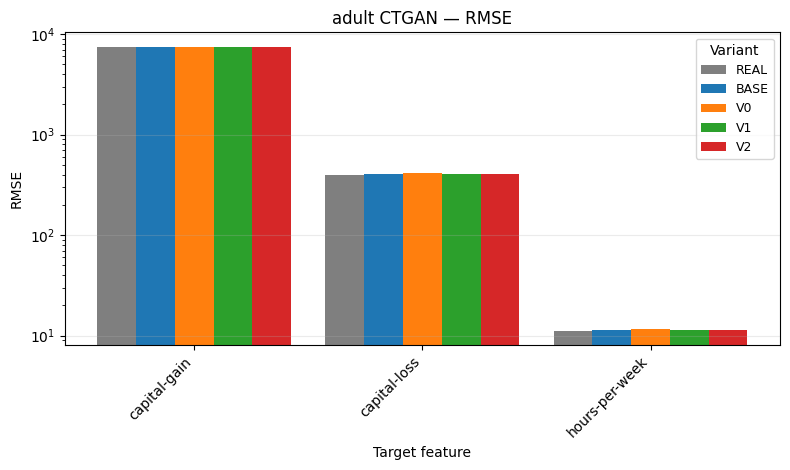

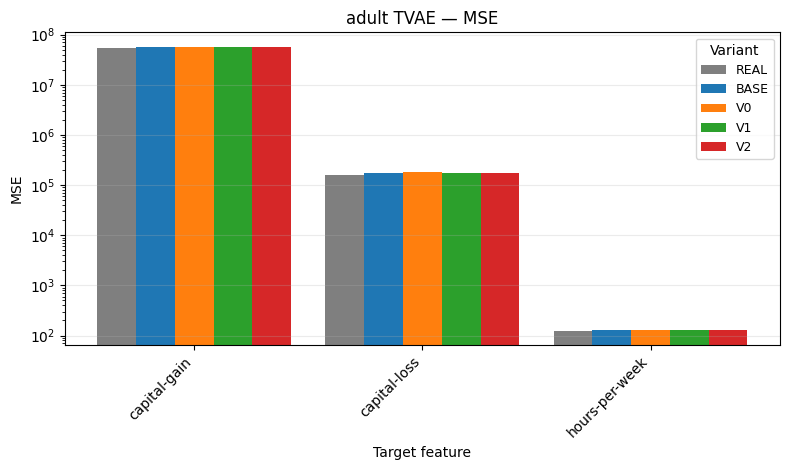

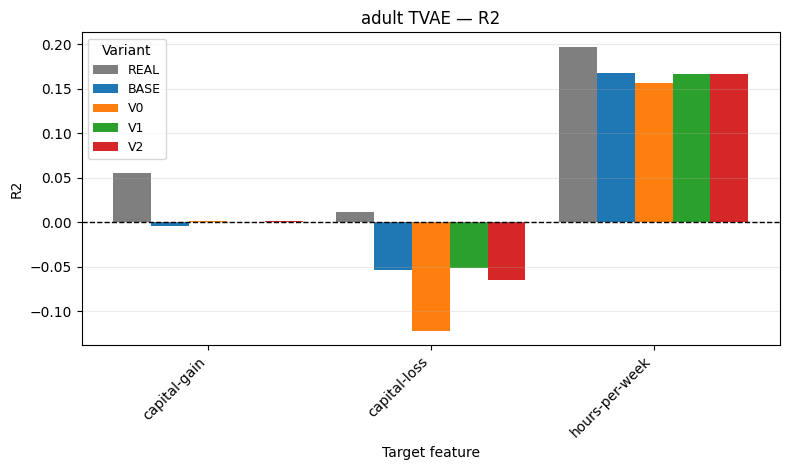

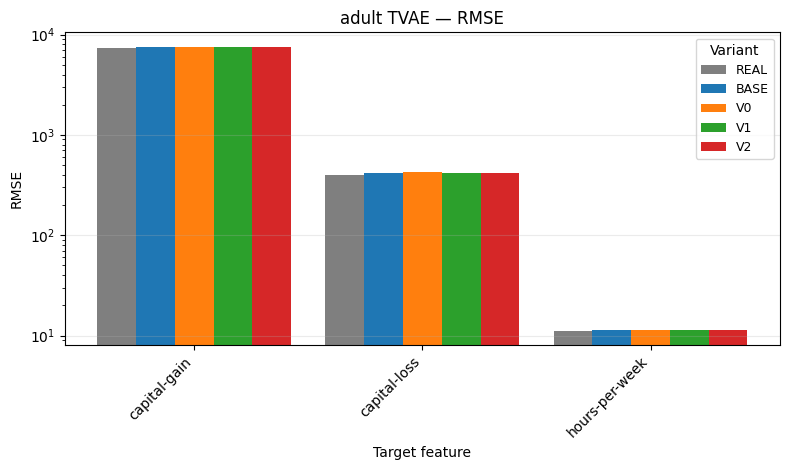

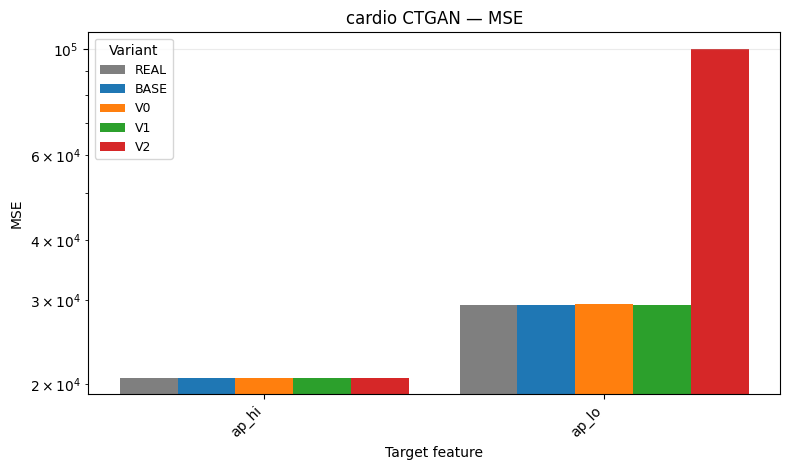

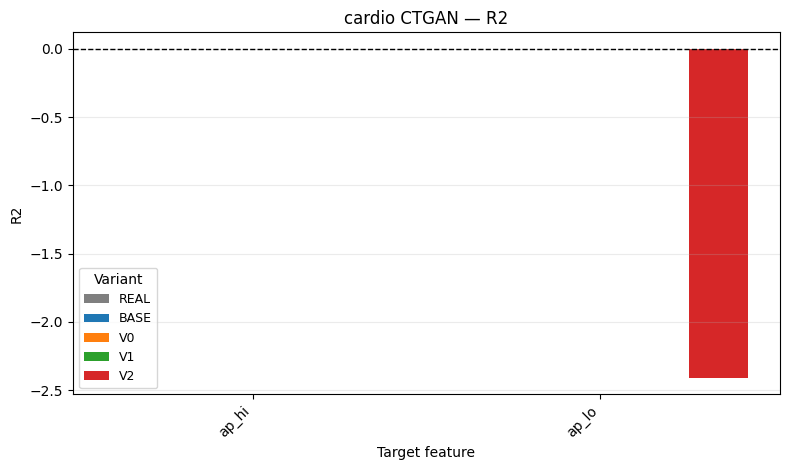

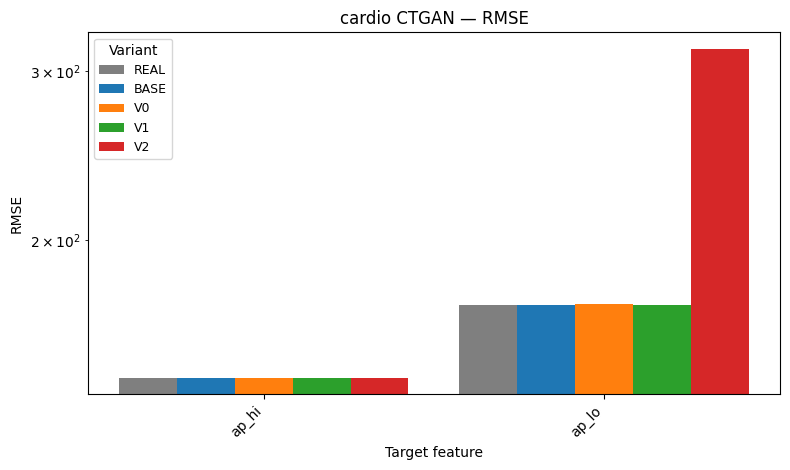

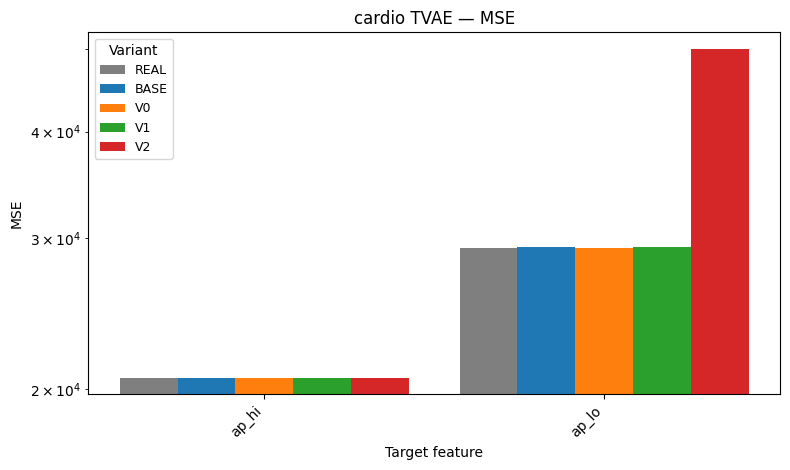

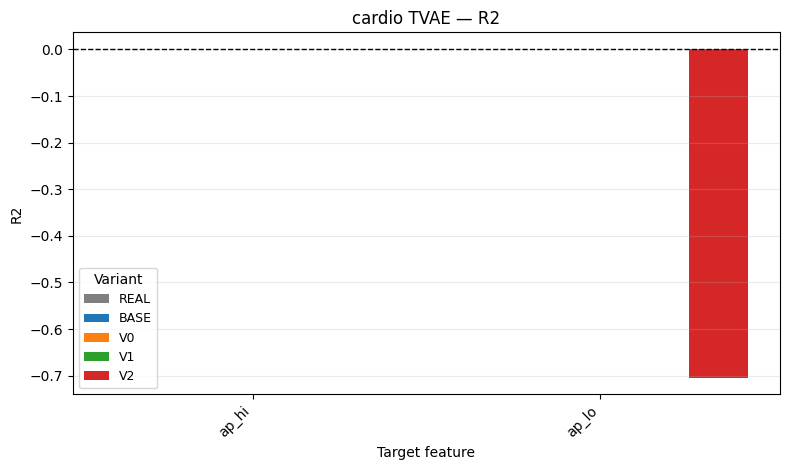

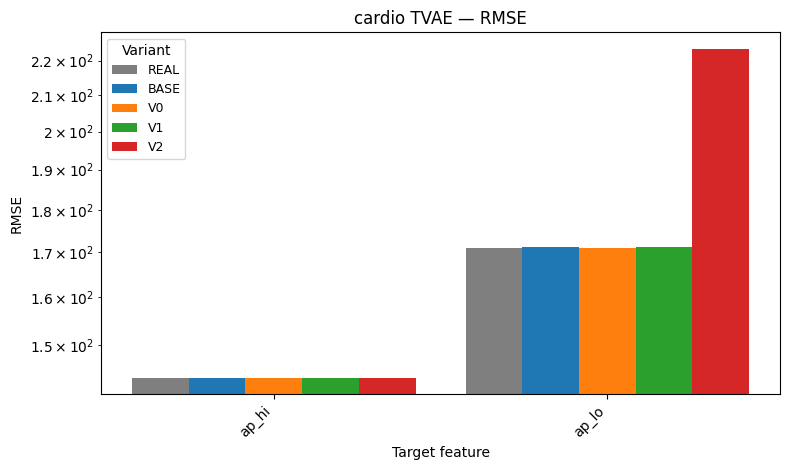

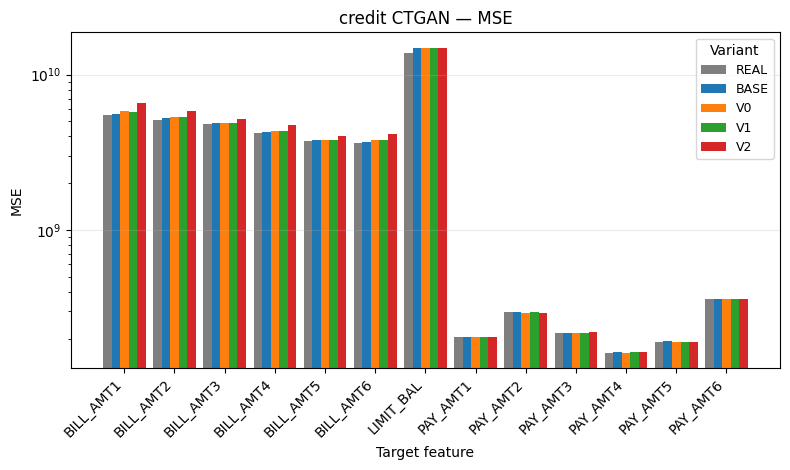

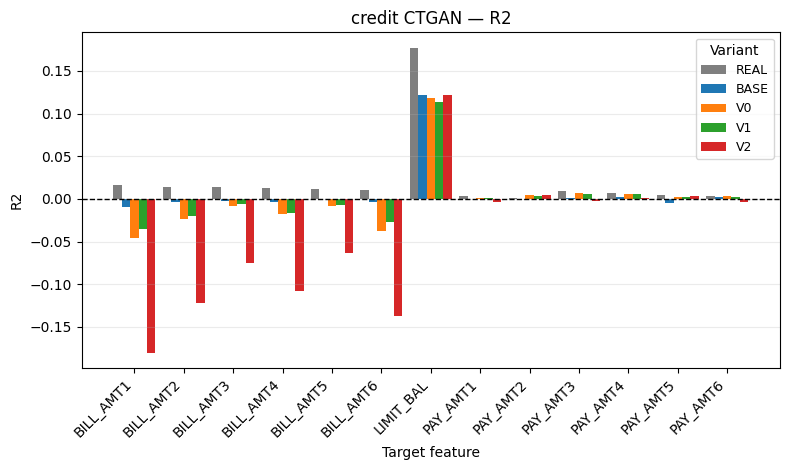

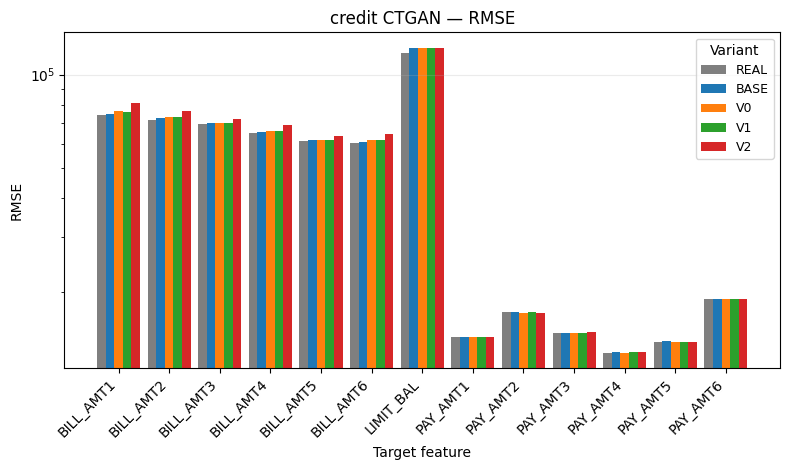

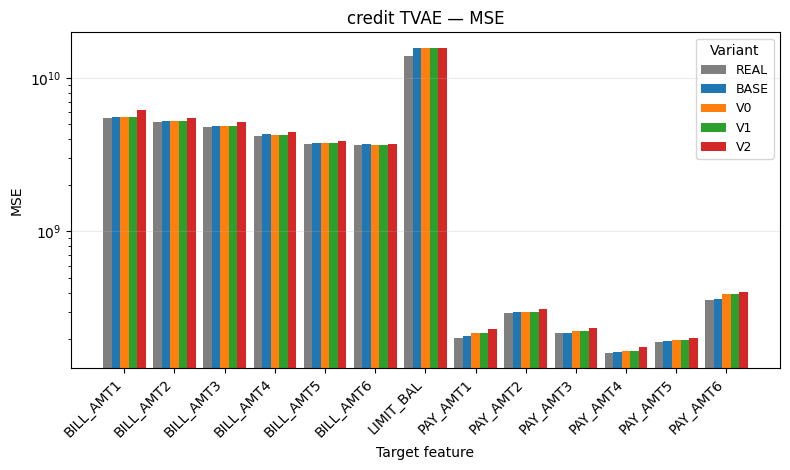

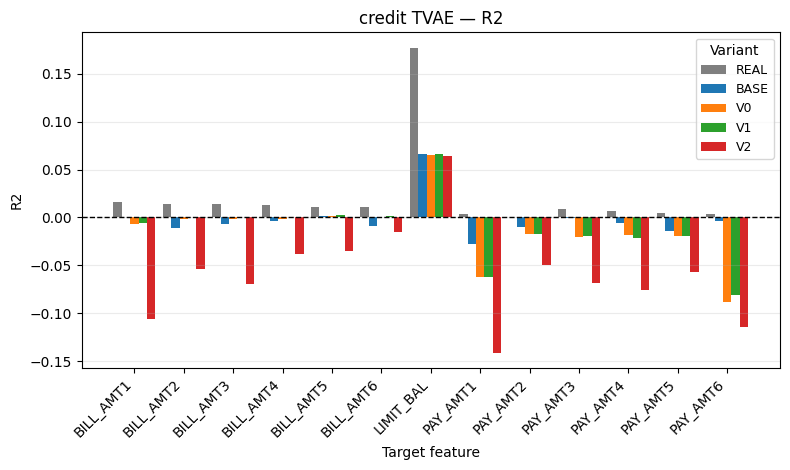

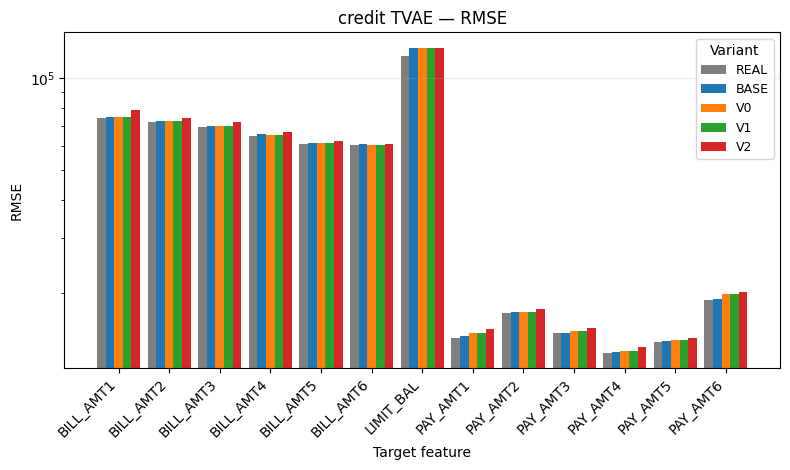

,group,variant,target,metric,value,family
0,credit CTGAN,credit REAL,BILL_AMT1,MSE,5.468560e+09,REAL
1,credit CTGAN,credit REAL,BILL_AMT1,R2,1.621770e-02,REAL
2,credit CTGAN,credit REAL,BILL_AMT1,RMSE,7.394972e+04,REAL
3,credit CTGAN,credit REAL,BILL_AMT2,MSE,5.132743e+09,REAL
4,credit CTGAN,credit REAL,BILL_AMT2,R2,1.417693e-02,REAL
...,...,...,...,...,...,...
535,cardio TVAE,cardio TVAE V2,ap_hi,R2,9.979800e-04,V2
536,cardio TVAE,cardio TVAE V2,ap_hi,RMSE,1.435454e+02,V2
537,cardio TVAE,cardio TVAE V2,ap_lo,MSE,4.997540e+04,V2
538,cardio TVAE,cardio TVAE V2,ap_lo,R2,-7.050593e-01,V2


In [33]:
from __future__ import annotations

from pathlib import Path
from typing import Any, Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def flatten_regression_dict(d: Dict[str, Any]) -> pd.DataFrame:
    rows: List[dict] = []
    for group, group_payload in d.items():
        if not isinstance(group_payload, dict):
            continue
        for variant, variant_payload in group_payload.items():
            if not isinstance(variant_payload, dict):
                continue
            for target, metrics_payload in variant_payload.items():
                if not isinstance(metrics_payload, dict):
                    continue
                for metric, value in metrics_payload.items():
                    if value is None:
                        continue
                    try:
                        v = float(value)
                    except Exception:
                        continue
                    rows.append(
                        dict(
                            group=str(group),
                            variant=str(variant),
                            target=str(target),
                            metric=str(metric),
                            value=v,
                        )
                    )
    return pd.DataFrame(rows)


def variant_family(variant_name: str) -> str:
    """
    Map full variant strings to a canonical family:
      REAL, BASE, V0, V1, V2, (or OTHER)
    Examples:
      "adult REAL" -> REAL
      "credit CTGAN" -> BASE
      "cardio TVAE V2" -> V2
    """
    s = variant_name.strip()
    # robust suffix checks
    if s.endswith("REAL") or " REAL" in s:
        return "REAL"
    for vx in ("V0", "V1", "V2", "V3", "V4", "V5"):
        if s.endswith(vx) or f" {vx}" in s:
            return vx
    return "BASE"


def plot_regression_feature_bars_consistent_colors(
    d: Dict[str, Any],
    metrics: List[str] | None = None,          # e.g. ["R2", "RMSE", "MSE"]
    include_real: bool = True,
    rotate_xticks: int = 45,
    save_dir: str | Path | None = None,
    logy_for: List[str] | None = None,         # default: ["MSE", "RMSE"]
    family_order: List[str] | None = None,     # default: REAL, BASE, V0, V1, V2
) -> pd.DataFrame:
    """
    One figure per (group, metric).
    X = target feature, Y = score, grouped bars = variants.
    Colors are consistent across *all* datasets/generators for the same family (BASE/V0/V1/V2/REAL).
    """
    df = flatten_regression_dict(d)
    if df.empty:
        raise ValueError("No plottable numeric values found in the provided dict.")

    df["family"] = df["variant"].map(variant_family)

    if not include_real:
        df = df[df["family"] != "REAL"].copy()

    if metrics is not None:
        df = df[df["metric"].isin(metrics)].copy()

    if logy_for is None:
        logy_for = ["MSE", "RMSE"]

    if family_order is None:
        family_order = ["REAL", "BASE", "V0", "V1", "V2"]

    # Consistent colors by family (Matplotlib default tab colors)
    family_color = {
        "REAL": "tab:gray",
        "BASE": "tab:blue",
        "V0": "tab:orange",
        "V1": "tab:green",
        "V2": "tab:red",
        "V3": "tab:purple",
        "V4": "tab:brown",
        "V5": "tab:pink",
        "OTHER": "tab:cyan",
    }

    out_dir = Path(save_dir) if save_dir is not None else None
    if out_dir is not None:
        out_dir.mkdir(parents=True, exist_ok=True)

    for group in sorted(df["group"].unique()):
        dfg = df[df["group"] == group]

        for metric in sorted(dfg["metric"].unique()):
            dfm = dfg[dfg["metric"] == metric].copy()

            # pivot by family (not full variant name) => matches your requirement
            pivot = (
                dfm.pivot_table(index="target", columns="family", values="value", aggfunc="mean")
                .sort_index()
            )

            # enforce column order
            cols = list(pivot.columns)
            ordered = [c for c in family_order if c in cols]
            remaining = [c for c in cols if c not in ordered]
            pivot = pivot[ordered + sorted(remaining)]

            targets = list(pivot.index)
            fams = list(pivot.columns)

            x = np.arange(len(targets))
            n = max(1, len(fams))
            width = min(0.85 / n, 0.22)

            fig_w = max(8.0, 0.60 * len(targets))
            fig_h = 4.8
            plt.figure(figsize=(fig_w, fig_h))

            for i, fam in enumerate(fams):
                y = pivot[fam].to_numpy(dtype=float)
                offset = (i - (n - 1) / 2) * width
                plt.bar(
                    x + offset,
                    y,
                    width=width,
                    label=fam,
                    color=family_color.get(fam, family_color["OTHER"]),
                )

            plt.title(f"{group} — {metric}")
            plt.xlabel("Target feature")
            plt.ylabel(metric)
            plt.xticks(x, targets, rotation=rotate_xticks, ha="right")
            plt.grid(True, which="major", axis="y", alpha=0.25)

            if metric in logy_for:
                # safe log scale
                vals = pivot.to_numpy(dtype=float)
                finite = vals[np.isfinite(vals)]
                if finite.size and np.nanmin(finite) > 0:
                    plt.yscale("log")

            if metric == "R2":
                plt.axhline(0.0, linestyle="--", linewidth=1.0, color="black")

            plt.legend(fontsize=9, title="Variant")
            plt.tight_layout()

            if out_dir is not None:
                fname = f"{group}__{metric}".replace("/", "_").replace(" ", "_") + ".png"
                plt.savefig(out_dir / fname, dpi=200)

            plt.show()

    return df


# -------------------------
# Usage
# -------------------------
# reg_results = <your regression dict>
plot_regression_feature_bars_consistent_colors(regression, metrics=["R2", "RMSE", "MSE"], include_real=True)
#
# Save:
# plot_regression_feature_bars_consistent_colors(reg_results, metrics=["R2","RMSE"], save_dir="reg_bars_consistent")


,dataset,generator,setting,Accuracy,weighted_F1
0,adult,CTGAN,V0,-0.007463,-0.002014
1,adult,CTGAN,V1,-0.011824,-0.007075
2,adult,CTGAN,V2,0.003685,0.001690
3,adult,TVAE,V0,-0.022388,-0.013139
4,adult,TVAE,V1,-0.011025,-0.006043
5,adult,TVAE,V2,-0.008261,-0.005399
6,cardio,CTGAN,V0,-0.035413,-0.016204
7,cardio,CTGAN,V1,-0.029937,-0.013389
8,cardio,CTGAN,V2,-0.043611,-0.028191
9,cardio,TVAE,V0,-0.035532,-0.015011


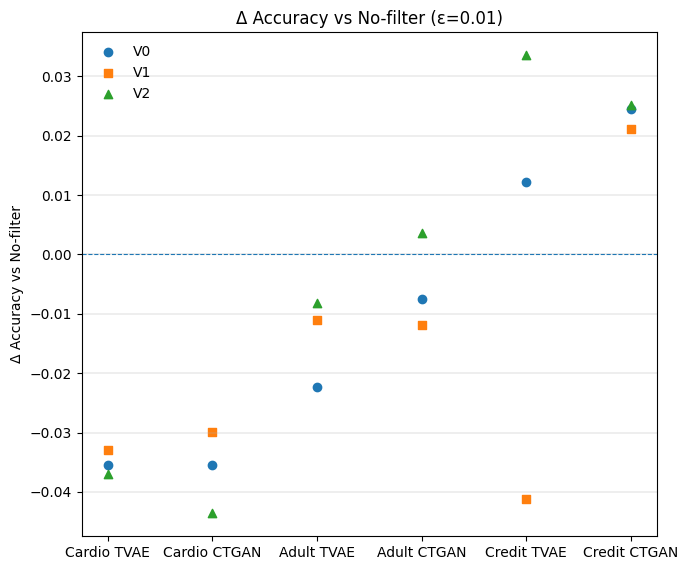

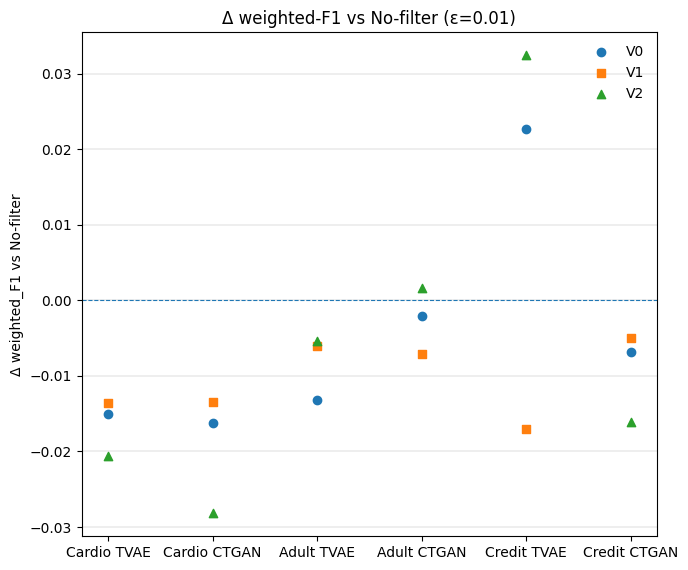

,dataset,generator,setting,R2,RMSE
0,adult,CTGAN,V0,-0.020492,1.049397
1,adult,CTGAN,V1,0.001785,-4.788335
2,adult,CTGAN,V2,0.005298,-4.856449
3,adult,TVAE,V0,-0.024791,-2.001051
4,adult,TVAE,V1,0.001941,-6.064428
5,adult,TVAE,V2,-0.002291,-6.458412
6,cardio,CTGAN,V0,-0.001259,0.107027
7,cardio,CTGAN,V1,-0.000639,0.053528
8,cardio,CTGAN,V2,-1.206682,72.577086
9,cardio,TVAE,V0,0.000634,-0.054498


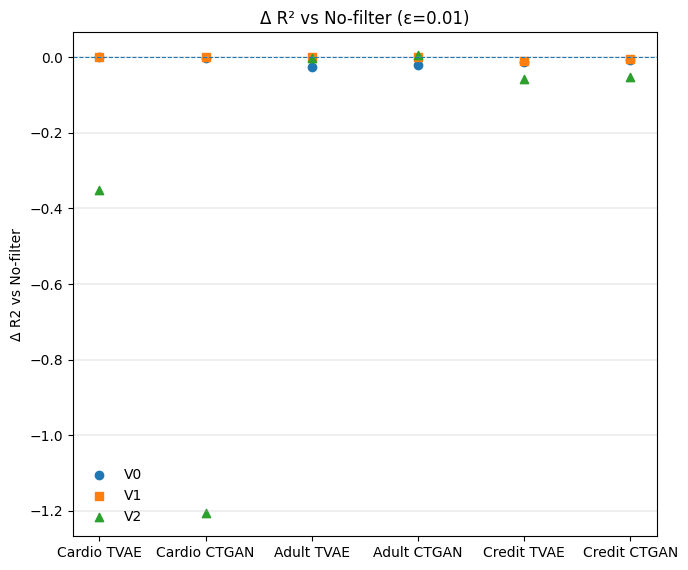

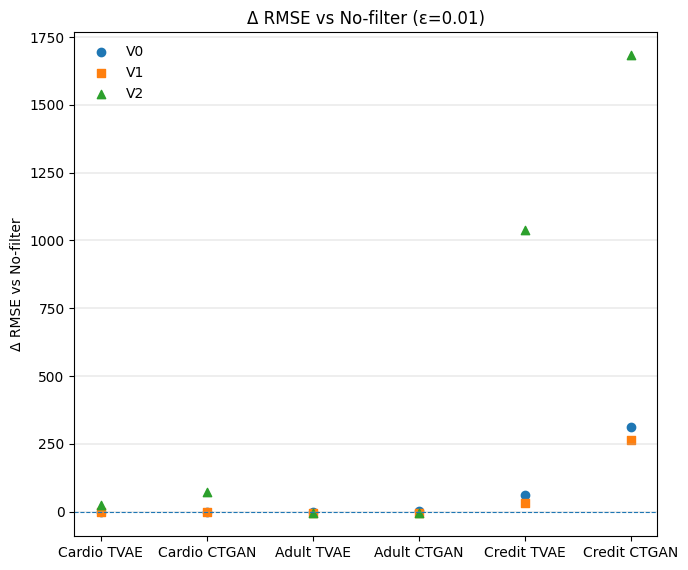

In [19]:
# ================== AIA inline plots + LaTeX tables (handles extra nesting) ==================
# Works with your variables: `classifications` and `regressions`.
# matplotlib only; one chart per figure; no explicit colors; ε_ANY = 0.01 fixed.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# --- map to expected names
if 'classification' not in globals():
    if 'classifications' in globals():
        classification = classifications
    else:
        raise NameError("Please define `classifications` (your big dict of classification results).")
if 'regression' not in globals():
    if 'regressions' in globals():
        regression = regressions
    else:
        regression = {}  # optional

CASES = [
    ("credit", "CTGAN"),
    ("credit", "TVAE"),
    ("adult",  "CTGAN"),
    ("adult",  "TVAE"),
    ("cardio", "CTGAN"),
    ("cardio", "TVAE"),
]

# ------------------ helpers ------------------
def _split_top_key(k: str):
    parts = k.split()
    ds = parts[0] if parts else ""
    gen = parts[1] if len(parts) > 1 else ""
    return ds, gen

def _detect_setting(k: str) -> str:
    if k.endswith(" V0"): return "V0"
    if k.endswith(" V1"): return "V1"
    if k.endswith(" V2"): return "V2"
    parts = k.split()
    if len(parts) > 1 and parts[1] == "REAL": return "REAL"
    return "no_filter"

def _to_rows_extra_nested(block: dict, task: str):
    """
    Correctly read setting from the INNER (mid) key, e.g.:
      top_key='credit CTGAN'
        └─ mid_key ∈ {'credit REAL', 'credit CTGAN', 'credit CTGAN V0', 'credit CTGAN V1', 'credit CTGAN V2'}
             └─ attribute -> metrics
    """
    rows = []
    for _outer_key, inner in block.items():
        if not isinstance(inner, dict):
            continue
        for mid_key, attr_map in inner.items():
            if not isinstance(attr_map, dict):
                continue
            ds, gen = _split_top_key(mid_key)          # <-- take ds/gen from INNER key
            st       = _detect_setting(mid_key)        # <-- take setting from INNER key
            for attr, metrics in attr_map.items():
                if not isinstance(metrics, dict):
                    continue
                if task == "classification":
                    if ("Accuracy" in metrics) and ("weighted F1" in metrics):
                        rows.append({
                            "dataset": ds, "generator": gen, "setting": st, "attribute": attr,
                            "Accuracy": float(metrics["Accuracy"]),
                            "weighted_F1": float(metrics["weighted F1"]),
                        })
                else:  # regression
                    if ("R2" in metrics) and ("RMSE" in metrics):
                        rows.append({
                            "dataset": ds, "generator": gen, "setting": st, "attribute": attr,
                            "R2": float(metrics["R2"]), "RMSE": float(metrics["RMSE"]),
                        })
    return rows


def _summarize(df: pd.DataFrame, task: str) -> pd.DataFrame:
    if df.empty: 
        return df
    cols = ["Accuracy","weighted_F1"] if task=="classification" else ["R2","RMSE"]
    cols = [c for c in cols if c in df.columns]
    return df.groupby(["dataset","generator","setting"], as_index=False)[cols].mean()


def _compute_deltas(sum_df: pd.DataFrame, metrics):
    rows = []
    for (ds, gen), grp in sum_df.groupby(["dataset","generator"]):
        if "no_filter" not in set(grp["setting"]): 
            continue
        ref = grp[grp["setting"]=="no_filter"].iloc[0]
        for setting in ["V0","V1","V2"]:
            if setting not in set(grp["setting"]):
                continue
            cur = grp[grp["setting"]==setting].iloc[0]
            row = {"dataset": ds, "generator": gen, "setting": setting}
            for m in metrics:
                if m in grp.columns:
                    row[m] = float(cur[m]) - float(ref[m])
            rows.append(row)
    return pd.DataFrame(rows)

def _forest_plot_inline(df_delta: pd.DataFrame, metric: str, title: str):
    if df_delta.empty or metric not in df_delta.columns:
        print(f"[warn] No data for forest plot metric={metric}")
        return

    df = df_delta.copy()
    df["case"] = df["dataset"].str.title() + " " + df["generator"]

    order = [f"{ds.title()} {gen}" for ds, gen in CASES if f"{ds.title()} {gen}" in set(df["case"])]
    df["case"] = pd.Categorical(df["case"], categories=order, ordered=True)
    df = df.sort_values(["case", "setting"])

    plt.figure(figsize=(7, 4 + 0.3 * len(order)))

    x_positions = {case: i for i, case in enumerate(order)}

    for setting, marker in zip(["V0", "V1", "V2"], ["o", "s", "^"]):
        sub = df[df["setting"] == setting]
        if sub.empty:
            continue

        xs = [x_positions[c] for c in sub["case"]]
        ys = sub[metric].values
        plt.scatter(xs, ys, marker=marker, label=setting)

    plt.xticks(range(len(order)), order)
    plt.axhline(0.0, linestyle="--", linewidth=0.8)
    plt.ylabel(f"Δ {metric} vs No-filter")
    plt.title(title)
    plt.grid(True, axis="y", linewidth=0.3)
    plt.legend(frameon=False)

    ax = plt.gca()
    ax.invert_xaxis()   # optional: reverse case order
    # ax.invert_yaxis() # ❌ remove this

    plt.tight_layout()
    plt.show()



# ------------------ 1) Build tidy frames (with extra nesting) ------------------
clf_rows = _to_rows_extra_nested(classification, task="classification")
df_clf = pd.DataFrame(clf_rows)
if df_clf.empty:
    raise ValueError("Parsed 0 rows from `classifications`. The parser now expects the extra nesting level you have.")

sum_clf = _summarize(df_clf, "classification")

df_reg = pd.DataFrame()
sum_reg = pd.DataFrame()
if regression:
    reg_rows = _to_rows_extra_nested(regression, task="regression")
    df_reg = pd.DataFrame(reg_rows)
    if not df_reg.empty:
        sum_reg = _summarize(df_reg, "regression")
    else:
        print("ℹ️ `regressions` provided but had no rows with both 'R2' and 'RMSE' (skipped).")



# ------------------ 3) Option B: Forest-of-Δ (inline) ------------------
delta_clf = _compute_deltas(sum_clf, ["Accuracy","weighted_F1"])
if not delta_clf.empty:
    display(delta_clf.sort_values(['dataset','generator','setting']).reset_index(drop=True))
    _forest_plot_inline(delta_clf, "Accuracy",     "Δ Accuracy vs No-filter (ε=0.01)")
    _forest_plot_inline(delta_clf, "weighted_F1", "Δ weighted-F1 vs No-filter (ε=0.01)")

if not sum_reg.empty:
    delta_reg = _compute_deltas(sum_reg, ["R2","RMSE"])
    if not delta_reg.empty:
        display(delta_reg.sort_values(['dataset','generator','setting']).reset_index(drop=True))
        _forest_plot_inline(delta_reg, "R2",   "Δ R² vs No-filter (ε=0.01)")
        _forest_plot_inline(delta_reg, "RMSE", "Δ RMSE vs No-filter (ε=0.01)")



=== Macro F1 comparison table ===
           real      None  eps 0.01  eps 0.01 weighted  eps 0.01 weighted 5
PAY_0  0.085963  0.092236  0.080626           0.090413             0.082024
PAY_2  0.100586  0.118631  0.096765           0.082057             0.088937
PAY_3  0.081612  0.093816  0.081091           0.083701             0.072887
PAY_4  0.085491  0.080071  0.087382           0.075780             0.080915
PAY_5  0.090138  0.085387  0.090411           0.081293             0.080841
PAY_6  0.087214  0.091039  0.093624           0.098277             0.082716


<Figure size 1000x600 with 0 Axes>

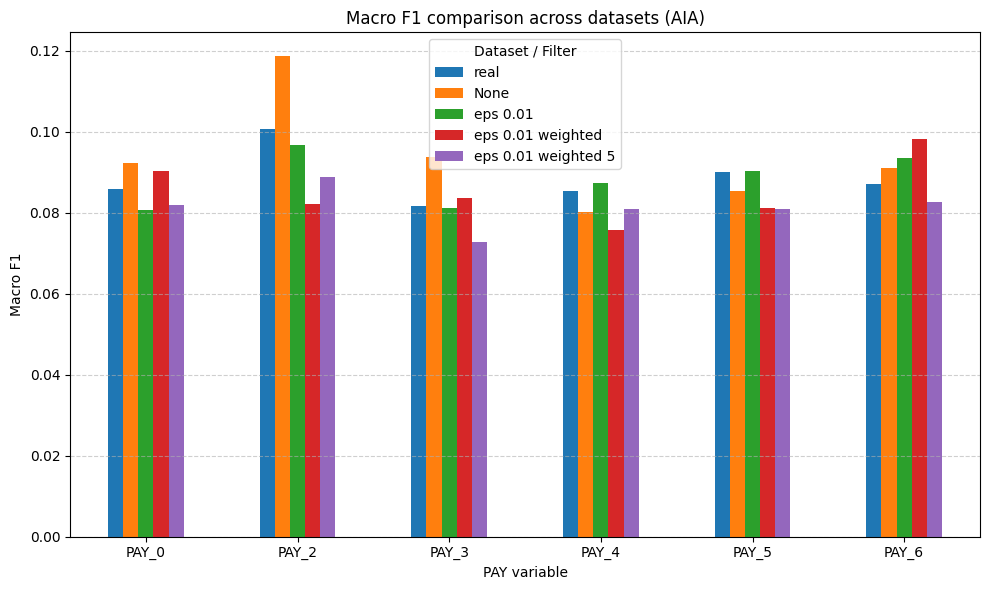

=== weighted F1 comparison table ===
           real      None  eps 0.01  eps 0.01 weighted  eps 0.01 weighted 5
PAY_0  0.360621  0.363764  0.341444           0.352402             0.338812
PAY_2  0.401876  0.390080  0.385213           0.388595             0.373097
PAY_3  0.396338  0.401662  0.387977           0.392385             0.373320
PAY_4  0.407575  0.408614  0.406194           0.400737             0.396340
PAY_5  0.416133  0.419077  0.415731           0.411709             0.412411
PAY_6  0.400978  0.409982  0.407037           0.413274             0.390946


<Figure size 1000x600 with 0 Axes>

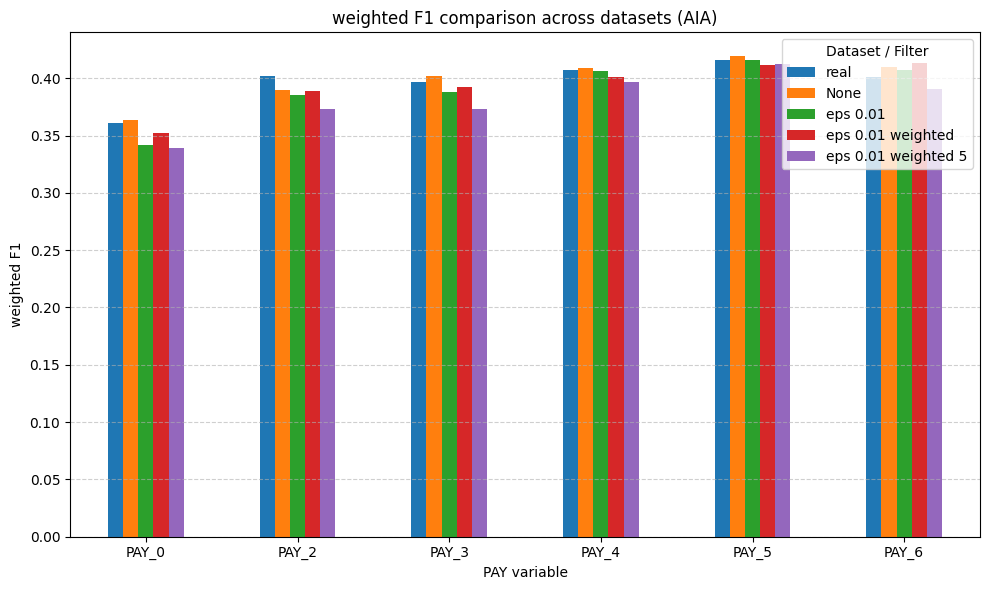

=== Accuracy comparison table ===
           real      None  eps 0.01  eps 0.01 weighted  eps 0.01 weighted 5
PAY_0  0.491833  0.443167  0.472167           0.460333             0.462333
PAY_2  0.524333  0.451833  0.499000           0.491333             0.498500
PAY_3  0.519500  0.470667  0.500167           0.499833             0.504000
PAY_4  0.535833  0.525333  0.525333           0.532000             0.527667
PAY_5  0.553000  0.539500  0.549667           0.543667             0.546667
PAY_6  0.542833  0.502000  0.530500           0.529667             0.537167


<Figure size 1000x600 with 0 Axes>

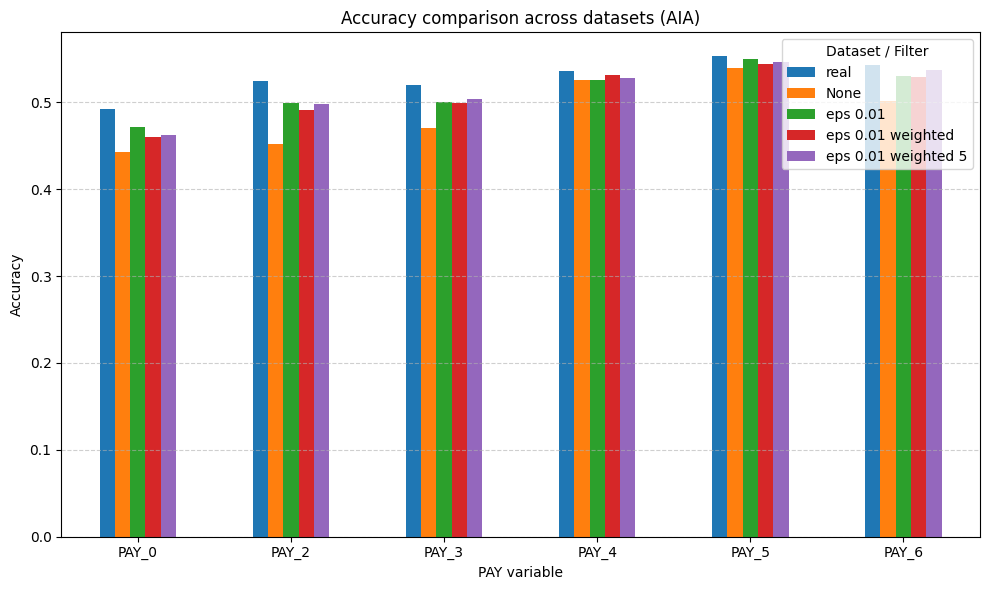

=== Balanced Accuracy comparison table ===
           real      None  eps 0.01  eps 0.01 weighted  eps 0.01 weighted 5
PAY_0  0.108263  0.110735  0.102481           0.105446             0.101865
PAY_2  0.120395  0.122487  0.114944           0.115346             0.111516
PAY_3  0.097996  0.099126  0.095104           0.096542             0.092004
PAY_4  0.104529  0.104490  0.103876           0.103420             0.101509
PAY_5  0.113979  0.113795  0.113403           0.112755             0.112879
PAY_6  0.113477  0.113613  0.114176           0.116197             0.110867


<Figure size 1000x600 with 0 Axes>

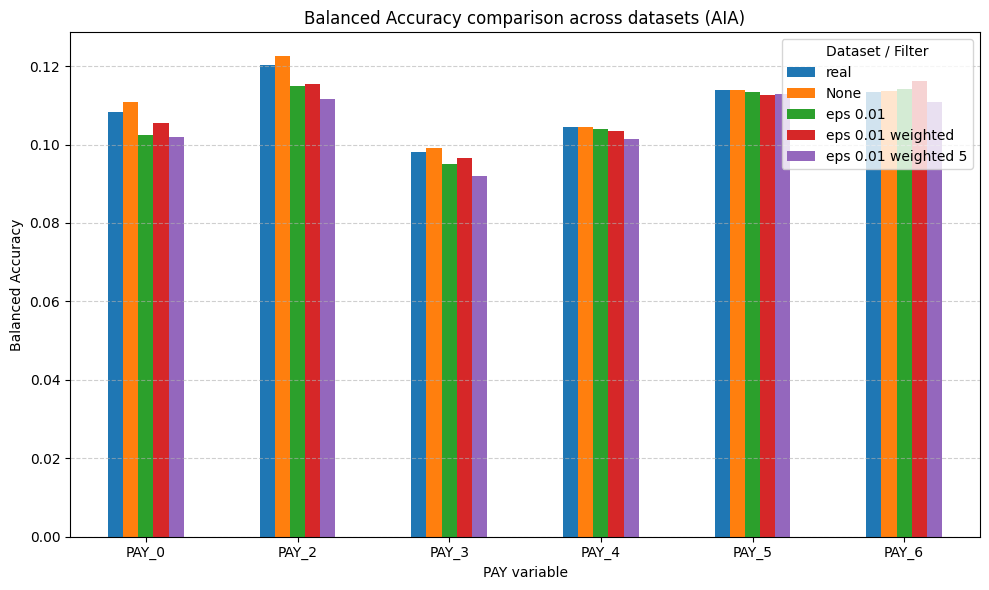

In [23]:
result_classification_plot(results, 'Macro F1')
result_classification_plot(results, 'weighted F1')
result_classification_plot(results, 'Accuracy')
result_classification_plot(results, 'Balanced Accuracy')

In [24]:
cat_risk = [column for column in adult_risk_column if column in cat_list_adult]
results = result_classification(predictions_aia_adult_ctgan, df_real_adult_test,cat_risk)

=== Macro F1 comparison table ===
            real      None  eps 0.01  eps 0.01 weighted  eps 0.01 weighted 5
income  0.747930  0.750149  0.751352           0.740380             0.752268
race    0.368678  0.319731  0.327274           0.330151             0.311251


<Figure size 1000x600 with 0 Axes>

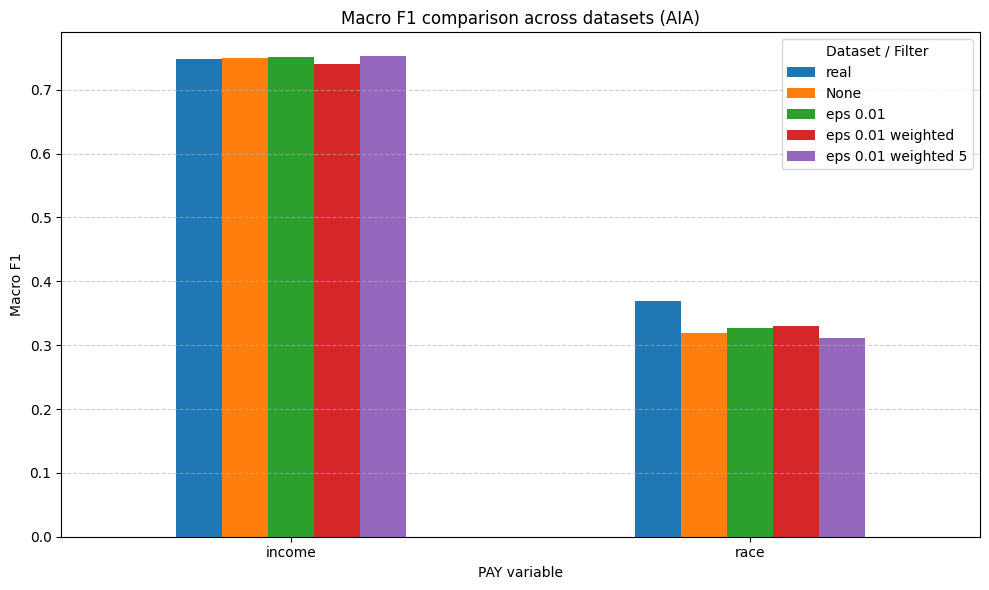

=== weighted F1 comparison table ===
            real      None  eps 0.01  eps 0.01 weighted  eps 0.01 weighted 5
income  0.825320  0.820348  0.821060           0.801067             0.821269
race    0.827678  0.797978  0.793238           0.803110             0.800436


<Figure size 1000x600 with 0 Axes>

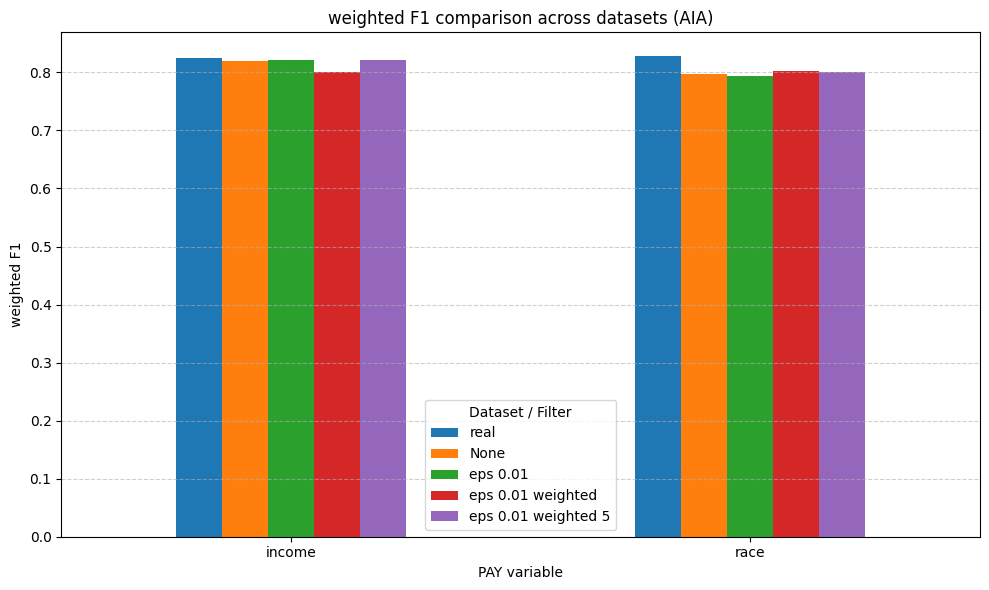

=== Accuracy comparison table ===
            real      None  eps 0.01  eps 0.01 weighted  eps 0.01 weighted 5
income  0.833303  0.821018  0.821571           0.791352             0.821325
race    0.855906  0.812788  0.797310           0.818807             0.819851


<Figure size 1000x600 with 0 Axes>

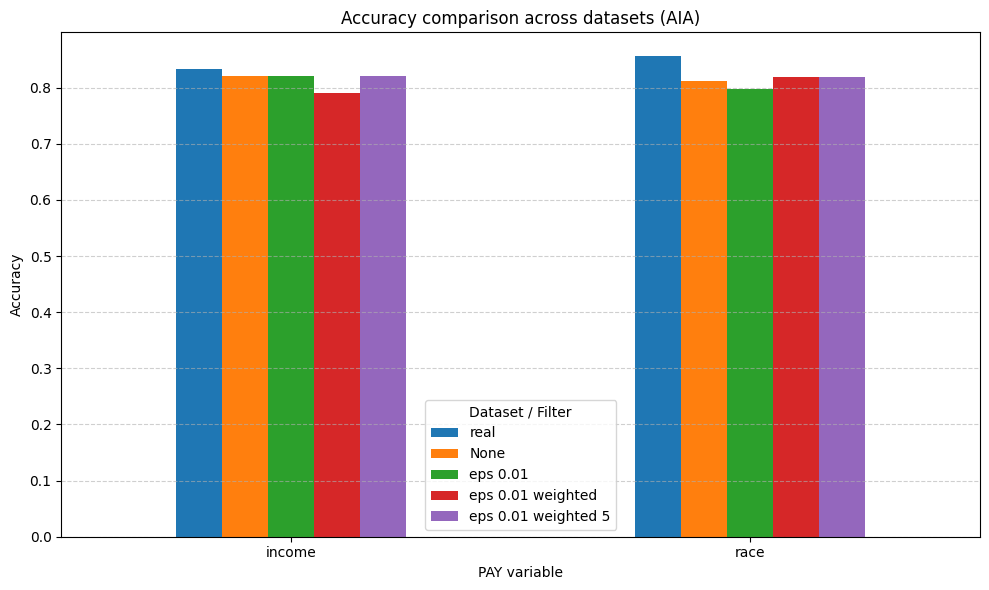

=== Balanced Accuracy comparison table ===
            real      None  eps 0.01  eps 0.01 weighted  eps 0.01 weighted 5
income  0.729240  0.748316  0.749935           0.772626             0.752109
race    0.349571  0.325850  0.328953           0.329486             0.315608


<Figure size 1000x600 with 0 Axes>

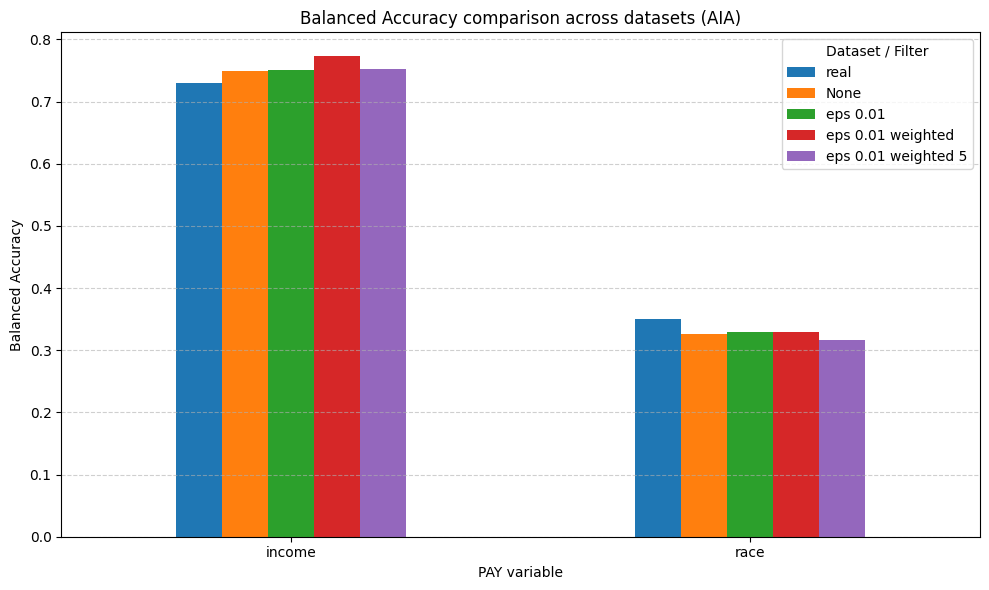

In [25]:
result_classification_plot(results, 'Macro F1')
result_classification_plot(results, 'weighted F1')
result_classification_plot(results, 'Accuracy')
result_classification_plot(results, 'Balanced Accuracy')


In [26]:
cat_risk = [column for column in adult_risk_column if column in cat_list_adult]
results = result_classification(predictions_aia_adult_tvae, df_real_adult_test,cat_risk)

=== Macro F1 comparison table ===
            real      None  eps 0.01  eps 0.01 weighted  eps 0.01 weighted 5
income  0.747930  0.745227  0.739368           0.747189             0.745987
race    0.368678  0.342905  0.315570           0.319309             0.332329


<Figure size 1000x600 with 0 Axes>

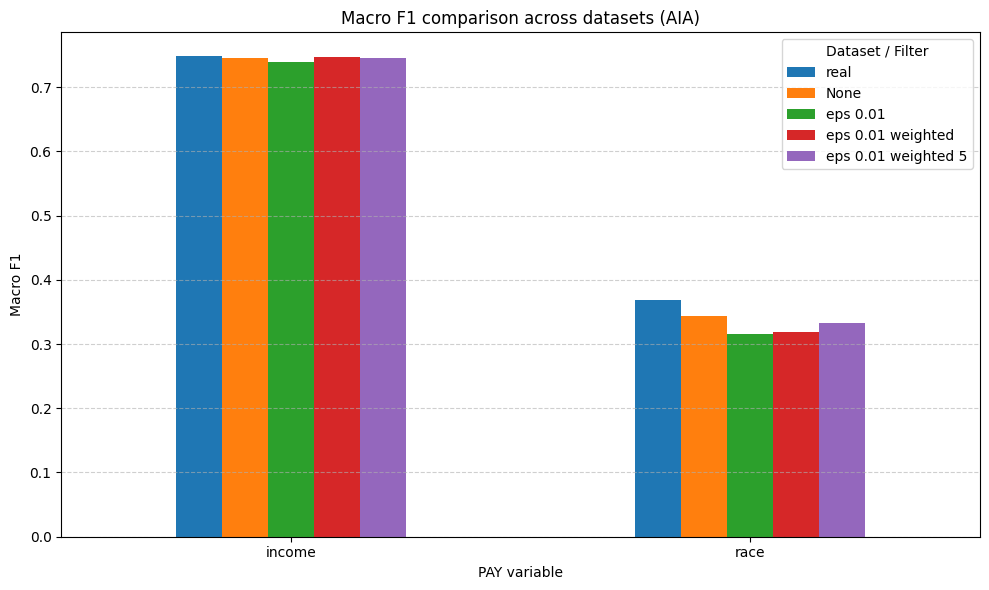

=== weighted F1 comparison table ===
            real      None  eps 0.01  eps 0.01 weighted  eps 0.01 weighted 5
income  0.825320  0.819508  0.812038           0.817900             0.813816
race    0.827678  0.823295  0.804487           0.812816             0.818188


<Figure size 1000x600 with 0 Axes>

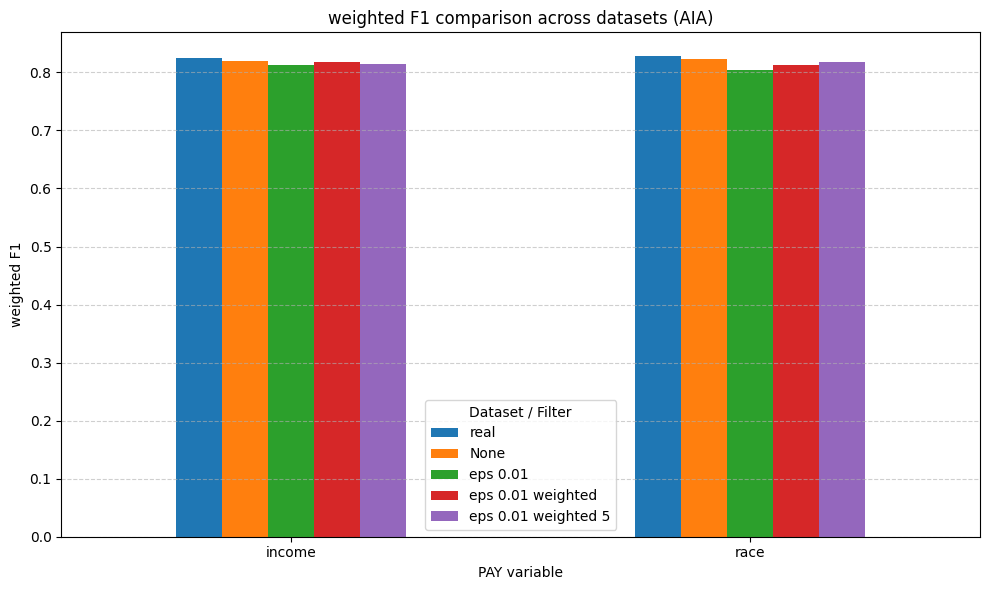

=== Accuracy comparison table ===
            real      None  eps 0.01  eps 0.01 weighted  eps 0.01 weighted 5
income  0.833303  0.823045  0.812174           0.818254             0.811068
race    0.855906  0.860328  0.826423           0.843069             0.855783


<Figure size 1000x600 with 0 Axes>

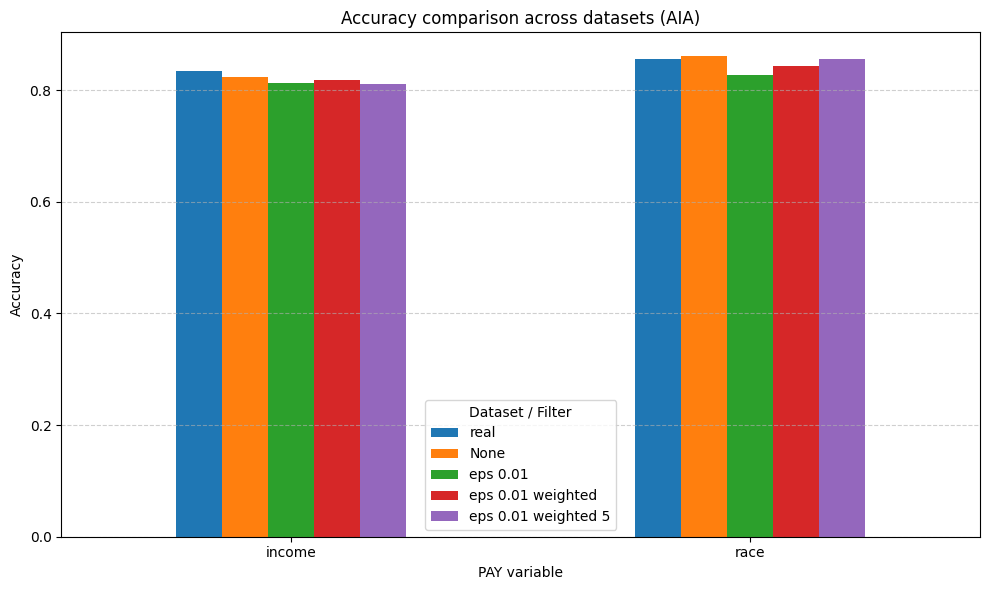

=== Balanced Accuracy comparison table ===
            real      None  eps 0.01  eps 0.01 weighted  eps 0.01 weighted 5
income  0.729240  0.736443  0.739024           0.746237             0.753835
race    0.349571  0.330431  0.321532           0.318887             0.324745


<Figure size 1000x600 with 0 Axes>

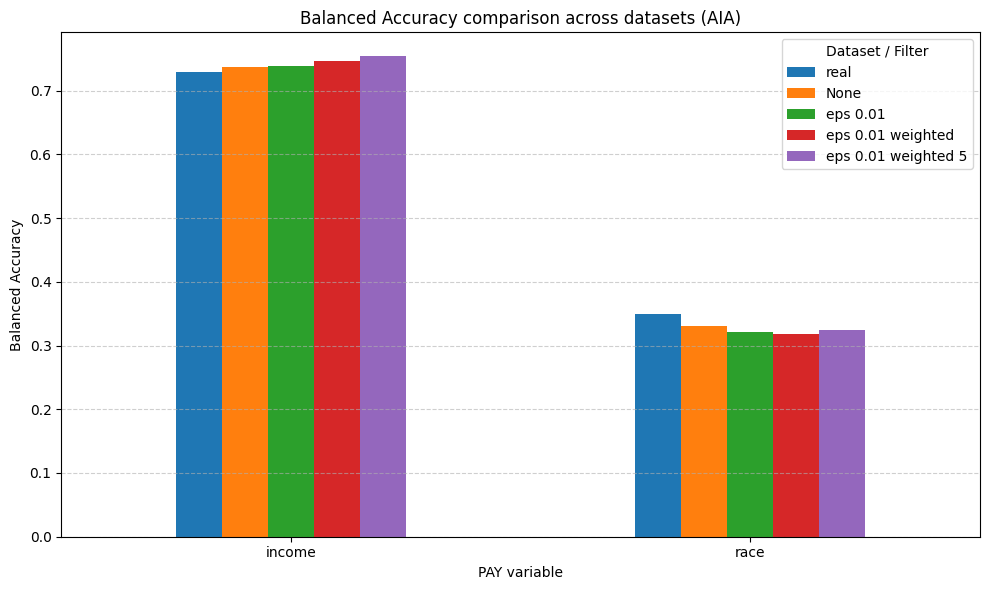

In [27]:
result_classification_plot(results, 'Macro F1')
result_classification_plot(results, 'weighted F1')
result_classification_plot(results, 'Accuracy')
result_classification_plot(results, 'Balanced Accuracy')

In [31]:
cat_risk = [column for column in cardio_risk_column if column in cat_list_cardio]
results = result_classification(predictions_aia_cardio_tvae, df_real_cardio_test,cat_risk)

=== Macro F1 comparison table ===
                 real      None  eps 0.01  eps 0.01 weighted  \
cholesterol  0.355578  0.349873  0.347425           0.346276   
gluc         0.342695  0.338137  0.337230           0.337095   
smoke        0.558321  0.551225  0.550269           0.556446   
alco         0.523012  0.520676  0.513038           0.508915   
active       0.501355  0.444768  0.501486           0.500725   

             eps 0.01 weighted 5  
cholesterol             0.341037  
gluc                    0.336148  
smoke                   0.556878  
alco                    0.520051  
active                  0.489904  


<Figure size 1000x600 with 0 Axes>

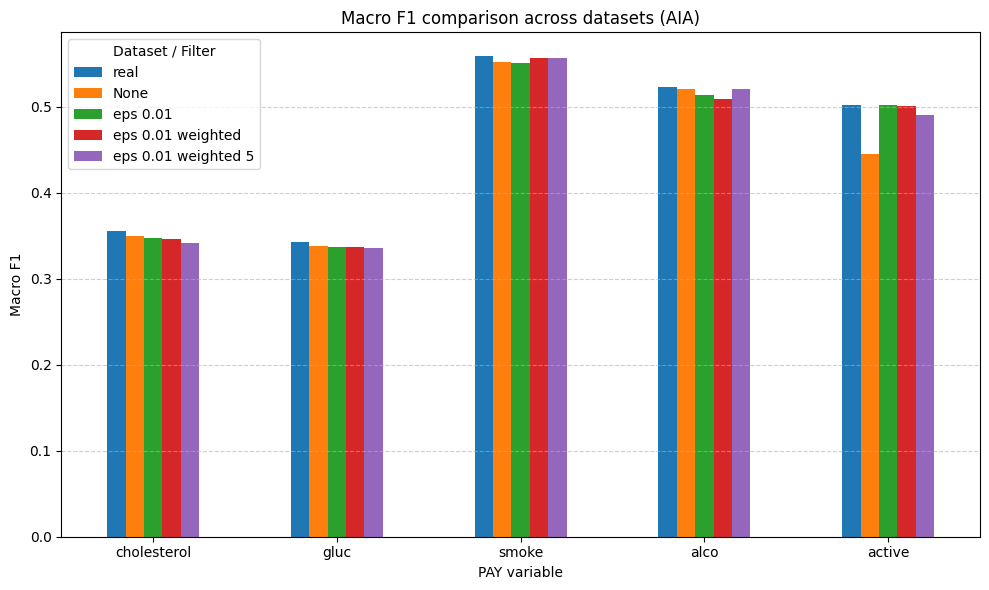

=== weighted F1 comparison table ===
                 real      None  eps 0.01  eps 0.01 weighted  \
cholesterol  0.599016  0.620334  0.591742           0.601040   
gluc         0.731153  0.725777  0.728089           0.728737   
smoke        0.858086  0.857943  0.859570           0.860032   
alco         0.899952  0.908198  0.905823           0.905737   
active       0.683597  0.712899  0.675351           0.671287   

             eps 0.01 weighted 5  
cholesterol             0.614243  
gluc                    0.699416  
smoke                   0.849828  
alco                    0.893690  
active                  0.706761  


<Figure size 1000x600 with 0 Axes>

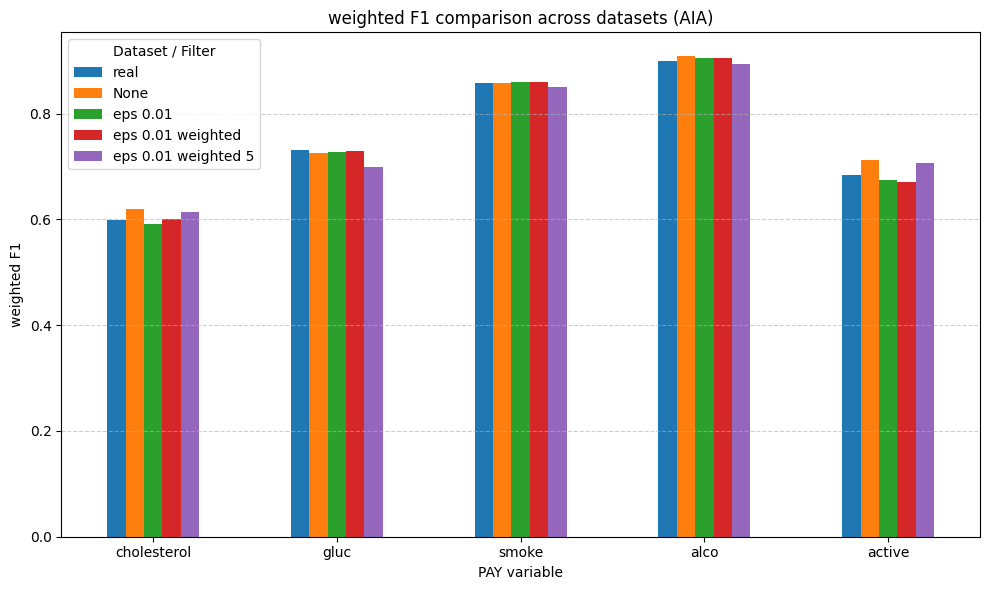

=== Accuracy comparison table ===
                 real      None  eps 0.01  eps 0.01 weighted  \
cholesterol  0.594571  0.645000  0.584762           0.604048   
gluc         0.722952  0.713000  0.718095           0.720048   
smoke        0.856238  0.858190  0.861762           0.860714   
alco         0.895476  0.912429  0.909190           0.909857   
active       0.684619  0.801048  0.668333           0.661048   

             eps 0.01 weighted 5  
cholesterol             0.637095  
gluc                    0.665857  
smoke                   0.840476  
alco                    0.883762  
active                  0.743571  


<Figure size 1000x600 with 0 Axes>

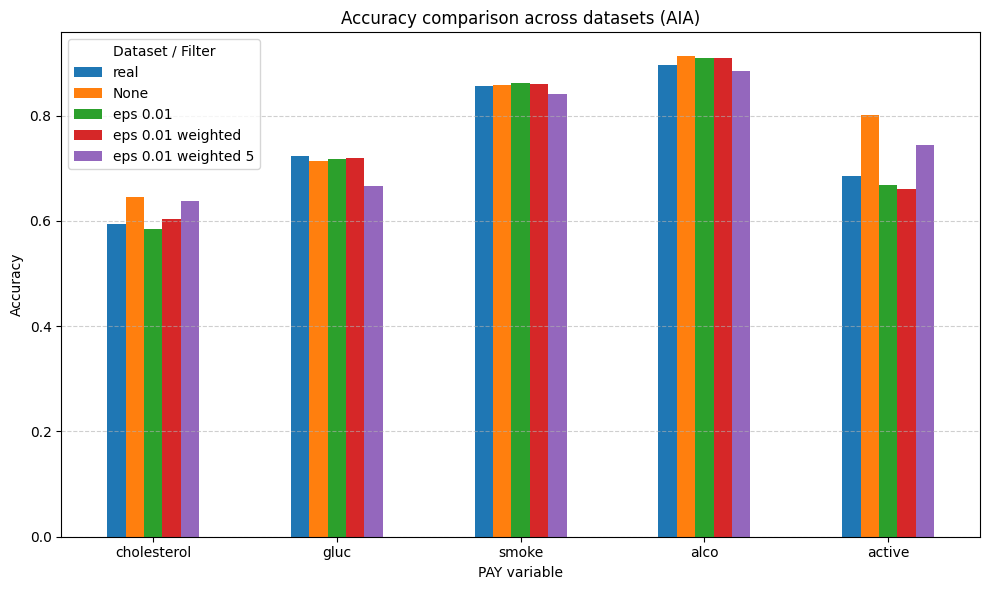

=== Balanced Accuracy comparison table ===
                 real      None  eps 0.01  eps 0.01 weighted  \
cholesterol  0.356150  0.349631  0.348059           0.345956   
gluc         0.343610  0.339320  0.337861           0.337637   
smoke        0.559906  0.551047  0.548783           0.555904   
alco         0.525464  0.519102  0.512289           0.508387   
active       0.501355  0.499762  0.502018           0.501802   

             eps 0.01 weighted 5  
cholesterol             0.342447  
gluc                    0.343276  
smoke                   0.565672  
alco                    0.525659  
active                  0.500252  


<Figure size 1000x600 with 0 Axes>

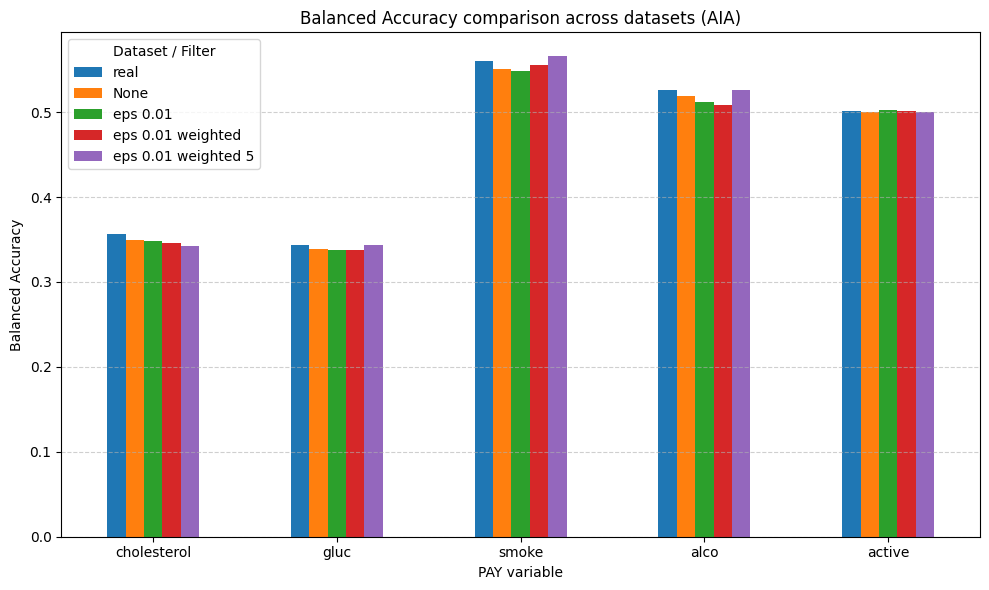

In [32]:
result_classification_plot(results, 'Macro F1')
result_classification_plot(results, 'weighted F1')
result_classification_plot(results, 'Accuracy')
result_classification_plot(results, 'Balanced Accuracy')

## other verifications

In [34]:

cardio_data_ctgan  = {
    'cardio REAL': df_real_cardio_train,
    'cardio CTGAN' : load_all_results(f'{PRIVACY_ONLY_DIR}/cardio_ctgan_baseline').generation_results.synthetic_data,
    'cardio CTGAN V0' : load_all_results(f'{PRIVACY_ONLY_DIR}/cardio_ctgan_eps_0.01').generation_results.synthetic_data,
    'cardio CTGAN V1' : load_all_results(f'{PRIVACY_ONLY_DIR_WEIGHTED}/cardio_ctgan_eps_0.01_weighted').generation_results.synthetic_data,   
    'cardio CTGAN V2' : load_all_results(f'{PRIVACY_ONLY_DIR_WEIGHTED_5}/cardio_ctgan_eps_0.01_weighted_5').generation_results.synthetic_data,  
}

dict_results_cardio_tvae_privacy  = {
    'cardio REAL': df_real_cardio_train,
    'cardio TVAE' : load_all_results(f'{PRIVACY_ONLY_DIR}/cardio_tvae_baseline').generation_results.synthetic_data,
    'cardio TVAE V0' : load_all_results(f'{PRIVACY_ONLY_DIR}/cardio_tvae_eps_0.01').generation_results.synthetic_data,
    'cardio TVAE V1' : load_all_results(f'{PRIVACY_ONLY_DIR_WEIGHTED}/cardio_tvae_eps_0.01_weighted').generation_results.synthetic_data,   
    'cardio TVAE V2' : load_all_results(f'{PRIVACY_ONLY_DIR_WEIGHTED_5}/cardio_tvae_eps_0.01_weighted_5').generation_results.synthetic_data,  
}


In [35]:
cardio_data_ctgan

{'cardio REAL':          age gender  height  weight  ap_hi  ap_lo cholesterol gluc smoke alco  \
 0      16047      1     168    70.0    130     90           1    1     0    0   
 1      14308      1     166    44.0     90     60           1    1     0    0   
 2      19824      1     160    65.0    120     80           1    1     0    0   
 3      21887      1     163    82.0    120     80           2    1     0    0   
 4      17451      1     158    70.0    120     80           1    1     0    0   
 ...      ...    ...     ...     ...    ...    ...         ...  ...   ...  ...   
 48995  23389      1     158    77.0    110     90           1    1     0    0   
 48996  23469      1     169    66.0    160     90           1    1     0    0   
 48997  16696      1     168    73.0    150    100           1    1     0    0   
 48998  18886      1     163    68.0    120     80           1    1     0    0   
 48999  20204      1     152    69.0    120     80           1    2     0    0   
 

In [20]:
import numpy as np
import pandas as pd

# -------------------------------
# Configuration
# -------------------------------
AP_LO_COL = "ap_lo"
PRED_NUM = ["age", "weight", "height"]
PRED_CAT = ["cholesterol", "gluc"]

# domain constraints (adjust if needed)
AP_LO_MIN_VALID = 30     # mmHg (physiological lower bound)
AP_LO_MAX_VALID = 200    # mmHg (very conservative upper bound)

# -------------------------------
# Helper functions
# -------------------------------
def summary_stats(x: pd.Series) -> dict:
    return {
        "min": x.min(),
        "max": x.max(),
        "mean": x.mean(),
        "std": x.std(ddof=1),
        "q01": x.quantile(0.01),
        "q05": x.quantile(0.05),
        "q50": x.quantile(0.50),
        "q95": x.quantile(0.95),
        "q99": x.quantile(0.99),
    }

def whisker_bounds(x: pd.Series) -> tuple:
    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    iqr = q3 - q1
    lo = q1 - 1.5 * iqr
    hi = q3 + 1.5 * iqr
    return lo, hi

def outlier_rate(x: pd.Series, lo: float, hi: float) -> float:
    return ((x < lo) | (x > hi)).mean()

def correlations(df: pd.DataFrame) -> dict:
    out = {}
    for col in PRED_NUM:
        if col in df.columns:
            out[f"corr_ap_lo_{col}"] = df[AP_LO_COL].corr(df[col])
    return out

def conditional_means(df: pd.DataFrame) -> dict:
    out = {}
    for col in PRED_CAT:
        if col in df.columns:
            out[f"mean_ap_lo_by_{col}"] = (
                df.groupby(col)[AP_LO_COL]
                  .mean()
                  .to_dict()
            )
    return out

def implausible_counts(x: pd.Series) -> dict:
    return {
        "neg_or_zero": (x <= 0).sum(),
        "below_domain_min": (x < AP_LO_MIN_VALID).sum(),
        "above_domain_max": (x > AP_LO_MAX_VALID).sum(),
    }

# -------------------------------
# Main analysis
# -------------------------------
def analyze_ap_lo(dfs: dict) -> pd.DataFrame:
    """
    dfs: dict[str, pd.DataFrame]
    returns: tidy DataFrame with one row per setting
    """
    results = []

    # reference whiskers from REAL / no-filter
    ref_df = dfs["cardio CTGAN"]
    ref_lo, ref_hi = whisker_bounds(ref_df[AP_LO_COL])

    for name, df in dfs.items():
        x = df[AP_LO_COL]

        row = {
            "setting": name,
            **summary_stats(x),
            "outlier_rate_vs_real_whiskers": outlier_rate(x, ref_lo, ref_hi),
            **correlations(df),
            **implausible_counts(x),
        }

        # attach conditional means as nested dicts
        row.update(conditional_means(df))

        results.append(row)

    return pd.DataFrame(results).set_index("setting")

# -------------------------------
# Run
# -------------------------------
ap_lo_report = analyze_ap_lo(cardio_data_ctgan)

# Pretty display (optional)
pd.set_option("display.max_colwidth", None)
print(ap_lo_report)


                 min   max        mean         std   q01   q05   q50     q95  \
setting                                                                        
cardio CTGAN      -7  1218   96.406633  119.049598  55.0  65.0  82.0   102.0   
cardio CTGAN V0   -7  1232  103.801102  145.764472  55.0  65.0  82.0   104.0   
cardio CTGAN V1  -11  1224  101.258776  137.290859  54.0  65.0  82.0   104.0   
cardio CTGAN V2  -56  1224  156.141388  261.388679  54.0  65.0  82.0  1043.0   

                    q99  outlier_rate_vs_real_whiskers  corr_ap_lo_age  \
setting                                                                  
cardio CTGAN     1046.0                       0.046776        0.057779   
cardio CTGAN V0  1080.0                       0.057122        0.054888   
cardio CTGAN V1  1074.0                       0.055061        0.054118   
cardio CTGAN V2  1135.0                       0.112755        0.090718   

                 corr_ap_lo_weight  corr_ap_lo_height  neg_or_zero  \
sett

In [36]:
import matplotlib.pyplot as plt
import numpy as np


def plot_ap_lo_distribution(data_dict, variant_a, variant_b, bins=50):
    """
    Plot the distribution of ap_lo for two selected variants.

    Parameters
    ----------
    data_dict : dict
        Your dictionary {variant_name: DataFrame}
    variant_a : str
        First variant key (e.g. "cardio REAL")
    variant_b : str
        Second variant key (e.g. "cardio CTGAN V2")
    bins : int
        Number of histogram bins
    """

    df_a = data_dict[variant_a]
    df_b = data_dict[variant_b]

    ap_lo_a = df_a["ap_lo"].to_numpy()
    ap_lo_b = df_b["ap_lo"].to_numpy()

    plt.figure(figsize=(7, 4.5))

    plt.hist(
        ap_lo_a,
        bins=bins,
        density=True,
        alpha=0.45,
        label=variant_a,
    )
    plt.hist(
        ap_lo_b,
        bins=bins,
        density=True,
        alpha=0.45,
        label=variant_b,
    )

    plt.xlabel("ap_lo")
    plt.ylabel("Density")
    plt.title("Distribution of ap_lo (Cardio dataset)")
    plt.legend()
    plt.grid(True, axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()


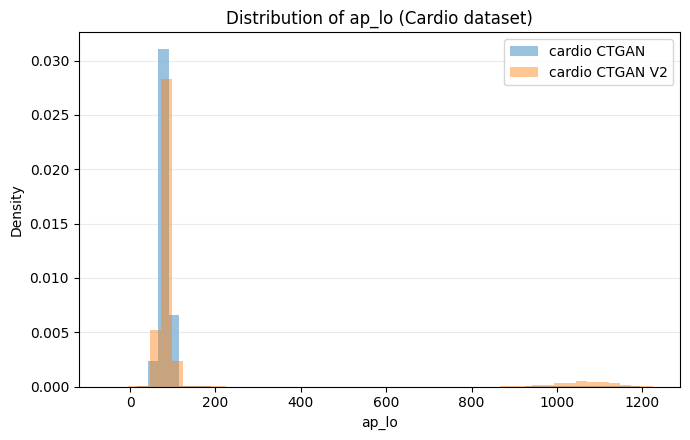

In [37]:
plot_ap_lo_distribution(cardio_data_ctgan, 'cardio CTGAN', 'cardio CTGAN V2', bins=50)

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde


def plot_ap_lo_density(
    data_dict,
    variant_a,
    variant_b,
    clip=None,          # e.g. (40, 140)
    bw_method="scott",  # or 0.2, 0.3, etc.
):
    """
    Plot KDE (line) distributions of ap_lo for two cardio variants.
    """

    a = data_dict[variant_a]["ap_lo"].to_numpy()
    b = data_dict[variant_b]["ap_lo"].to_numpy()

    if clip is not None:
        lo, hi = clip
        a = a[(a >= lo) & (a <= hi)]
        b = b[(b >= lo) & (b <= hi)]

    # common x-grid for fair comparison
    xmin = min(a.min(), b.min())
    xmax = max(a.max(), b.max())
    x = np.linspace(xmin, xmax, 600)

    kde_a = gaussian_kde(a, bw_method=bw_method)
    kde_b = gaussian_kde(b, bw_method=bw_method)

    plt.figure(figsize=(7, 4.5))

    plt.plot(x, kde_a(x), linewidth=2.2, label=variant_a)
    plt.plot(x, kde_b(x), linewidth=2.2, label=variant_b)

    plt.xlabel("ap_lo")
    plt.ylabel("Density")
    plt.title("Distribution of ap_lo (Cardio)")
    plt.grid(True, axis="y", alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()


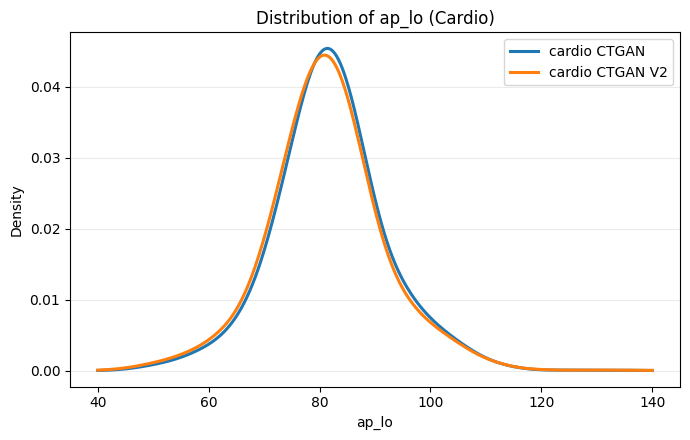

In [40]:
plot_ap_lo_density(
    cardio_data_ctgan,
    variant_a="cardio CTGAN",  variant_b ='cardio CTGAN V2',
    clip=(40, 140),     # optional but strongly recommended
    bw_method=0.25      # slightly smoother than default
)


In [41]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde


def plot_ap_lo_with_tail(
    data_dict,
    v1,
    v2,
    main_range=(40, 180),
    tail_range=(800, 1300),
    bw=0.25,
):
    a = data_dict[v1]["ap_lo"].to_numpy()
    b = data_dict[v2]["ap_lo"].to_numpy()

    kde_a = gaussian_kde(a, bw_method=bw)
    kde_b = gaussian_kde(b, bw_method=bw)

    fig, (ax1, ax2) = plt.subplots(
        1, 2, figsize=(9.5, 4.2),
        gridspec_kw={"width_ratios": [3, 1]},
        sharey=True
    )

    # Main body
    x1 = np.linspace(*main_range, 600)
    ax1.plot(x1, kde_a(x1), label=v1, lw=2)
    ax1.plot(x1, kde_b(x1), label=v2, lw=2)
    ax1.set_xlim(*main_range)
    ax1.set_xlabel("ap_lo (main range)")
    ax1.set_ylabel("Density")
    ax1.grid(axis="y", alpha=0.25)

    # Tail
    x2 = np.linspace(*tail_range, 400)
    ax2.plot(x2, kde_a(x2), lw=2)
    ax2.plot(x2, kde_b(x2), lw=2)
    ax2.set_xlim(*tail_range)
    ax2.set_xlabel("ap_lo (tail)")

    # Visual break markers
    ax1.spines["right"].set_visible(False)
    ax2.spines["left"].set_visible(False)
    ax2.tick_params(left=False)

    ax1.legend()
    fig.suptitle("ap_lo density with explicit tail visualization", y=1.02)
    plt.tight_layout()
    plt.show()


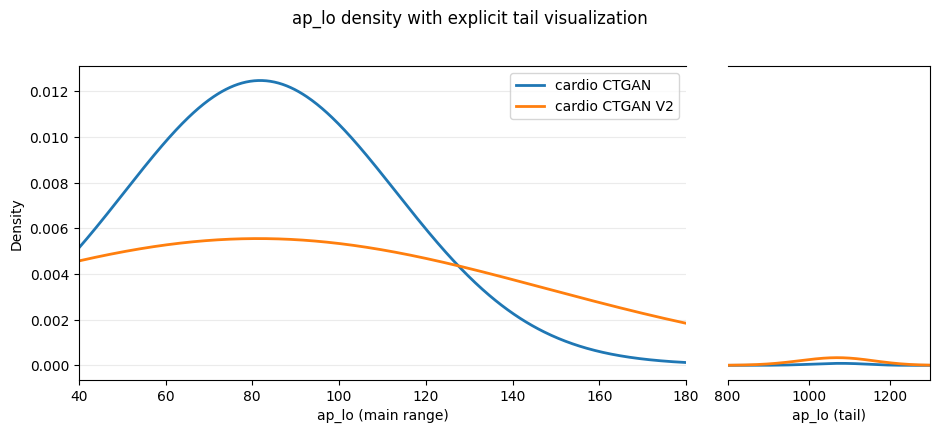

In [42]:
plot_ap_lo_with_tail(
    cardio_data_ctgan,
    "cardio CTGAN",
    "cardio CTGAN V2",
    main_range=(40, 180),
    tail_range=(800, 1300),
)